In [1]:
# Run only once to install new version of solo_epd_loader
#%pip install --upgrade solo_epd_loader
#%pip install solo_epd_loader==0.2.8
#%pip install solo_epd_loader==0.4.3

In [2]:
#%pip install sunpy==5.0.1

In [3]:
from epd_plot_shift import *
from run_the_fit import *
from solo_epd_loader import epd_load, calc_electrons, combine_pixels
species = 'e'

# Notebook to plot and fit SolO EPD SEE data
#### General information about the notebook:
This Notebook allows the user to load, plot and fit SolO EPD SEE energy data.
The particle data loading process uses solo-epd-loader. 
<br>This package can be installed simply by running   ``%pip install git+https://github.com/jgieseler/solo-epd-loader``    in any cell of the notebook. Note that this should only be done once. The package can be updated by running: ``%pip install git+https://github.com/jgieseler/solo-epd-loader --upgrade``
<br>The data will be saved as cdf files to a local folder provided by the user. The data is then used to create dataframes of the electron data for each instrument and energy channel. 
<br>This notebook also lets the user dowload pitch angle data, if available. This is useful in case of anisotropic events to check that the s/c sees the particle beam.
<br>The intensity data (and pitch angle data) will be plotted as a timeseries. The timeseries include all the energy channels for each instrument. (add  expl pa) A flux peak will be searchered for each energy channel using the provided injection time and following the velocity dispersion. These values will then be plotted against the energy corresponding to the channels to form a spectrum. 
<br>The spectrum can then be fit with various functions to analyse its shape.


### PATH, FOLDERS, EVENT
``path`` (string): a folder where you wish to save the data from the loading, plotting and fitting process. 
<br>``create_sub_folders`` (bool): if ``True``, a new folder will be created for each event and the data will be saved separately for each event. This is useful in case you wish to analyse multiple events and have all folders and data in a close location. Each new ``date`` input is counted as a new event.
<br> ``save_fit_run_variables_to_separate_folders``(bool): Use only if ``create_sub_folders`` is ``True``. If ``True``, this saves all the files with the fitting results into a folder outsite of the event folder as a copy. This is useful if you wish to analyse multiple events and wish to have all the final results from the different events in one folder.
<br> ``date`` (datetime): datetime(yyyy, mm, dd, HH, MM) or datetime(yyyy, mm, dd, HH, MM, ss). The date and approximate injection time of the event. This does not have to be an exact time, you will be able to look more carefully for the event peak later in the notebook, but you should choose a date and time that lets you identify the event easily.
<br> ``saving``(bool): If ``True`` all the plots from this notebook will be saved to ``path``
<br> ``pixels``(bool): if True all the separate pixel data for STEP willl be downloaded. Use only if you wish to use the centre pixwls of STEP.

In [4]:
path =   r'/Users/annafed/Desktop/Docs/debugging_folder/'
create_sub_folders = True
save_fit_run_variables_to_separate_folders = True # saves the file with the results from the fit and the one with all imput variables to separate folders

date = dt.datetime(2022, 11, 11, 11, 41)#, 40) #20221111-1141

saving = True
pixels = True


In [5]:
# DO NOT CHANGE, JUST RUN THIS CELL (some of these are in the process of being deleted)
threshold_folders = False # if true saving to separate folders does not work. (FEB 2026: Will be deleted soon, this was just for internal use! Leave to False)
plot_n_data_folders = True #saves plots in separate folders (NEEDS FIX IN DATA FOLDERS) 
date_string = str(date.date()) # DO NOT CHANGE

__Choose to use or not STEP, EPT and HET__
<br> NOTE: this is just to download and plot the data. You can still choose not to fit part of the data later.
<br> ``step`` (bool): if True step data will be dowloaded and plotted
<br> ``ept`` (bool): if True ept data will be dowloaded and plotted
<br> ``het`` (bool): if True het data will be dowloaded and plotted


__Choose a viewing direction and time averaging for the data__
<br> ``direction`` (string): 'sun', 'asun', 'north', 'south'    NOTE: STEP has 'sun' direction only. 
<br> ``avraging``(string):  data averaging expressed as pandas' strings e.g. '1s', '1min', '1h' etc
<br> Possible values:
<br>‘W’
<br>‘D’ / ‘days’ / ‘day’
<br>‘hours’ / ‘hour’ / ‘hr’ / ‘h’
<br>‘m’ / ‘minute’ / ‘min’ / ‘minutes’ / ‘T’
<br>‘S’ / ‘seconds’ / ‘sec’ / ‘second’
<br>‘ms’ / ‘milliseconds’ / ‘millisecond’ / ‘milli’ / ‘millis’ / ‘L’
<br>‘us’ / ‘microseconds’ / ‘microsecond’ / ‘micro’ / ‘micros’ / ‘U’
<br>‘ns’ / ‘nanoseconds’ / ‘nano’ / ‘nanos’ / ‘nanosecond’ / ‘N’

<br> ``ion_correction`` (bool): if True will use ion corrected EPT data (use only if inclusing EPT data)
<br> ``bg_subtraction`` (bool): if True will use background subtracted data (else choose False)



In [6]:
step = True
ept = True
het = True

direction = 'sun'
averaging = '2min'
contamination_threshold = None  # either None or an integer >0 (STEP)

ion_correction = True 
bg_subtraction = True

In [7]:
#JUST RUN
if averaging is None:
    averaging_str = 'no'
else:
    averaging_str = str(averaging)

``position`` this variable contains information about the location of Solar Orbiter on the day of the event as well as the travel time of light and electrons with energy corresponding to the lowest STEP energy channel (4 keV) and the highest HET energy channel (10 MeV).

In [8]:
position = position_and_traveltime(date, species) #JUST RUN but you should have sunpy 5.0.1 otherwise something breaks...

2026-09-16 17:08:40 - sunpy - INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144)


INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144) [sunpy.coordinates.ephemeris]
-------------------------------------------  ----  ------------------
Distance of SolO from the Sun                [AU]  0.62
Length of the Parker Spiral for 400 km/s sw  [AU]  0.6574115359138376
Travel time of 4 keV electrons                     0 h 43 min 57.2 s
Travel time of 10 MeV electrons                    0 h 5 min 28.4 s
Travel time of light                               0 h 5 min 9.4 s
-------------------------------------------  ----  ------------------


__LOADING DATA, PLOTTING TIMESERIES AND SPECTRUM (NO FIT)__
The following inputs can be changed, but the notebook will run without any changes.
<br> ``start_date`` and ``end_date`` (int or datetime): The start and end datetime to download data. It is set to +/- 6 hours. This is read from ``date``. Format: datetime(yyyy, mm, dd) or yyyymmdd.  You can just change the timedelta as you wish. e.g. +timedelta(minutes = 600) or -timedelta(hours = 4)
<br> ``plot_start`` and ``plot_end`` (string): The start and end time for the timeseries plot. It is set to +/- 5 hours. As for ``start_date`` and ``end_date`` , only change the timedelta part if needed. Do not change the rest of the code.
<br> ``plot_pa`` (bool, defauts to True): plots the pitch angle coverage for the event. 


In [9]:
startdate = date-dt.timedelta(hours = 8)
start_date = startdate.date()
enddate = date+dt.timedelta(hours = 8)
end_date = enddate.date()

plot_start = str(date-dt.timedelta(hours = 5))[:-3].replace(' ', '-').replace(':', '')
plot_end = str(date+dt.timedelta(hours = 5))[:-3].replace(' ', '-').replace(':', '')

plot_pa = True


__DO NOT CHANGE JUST RUN__
<br> ``t_inj`` (string): taken automatically from the previously defined value (date). In the following cell it is only used to create a path for the new folders to save the data. This value is changed later (before the plots e.g. by using the light travel time (position)) to fit the peak into the search window. This value is fixed to the highest HET channel (close traveltime to light tt for electrons), the rest of the window times are calculated using velocity dispersion.
<br> ``autodownload`` (bool, defaults to True): If True will automatically download the data to analyse the event.
<br> ``data_type`` (string, defaults to 'l2'): 'll' = low latency, 'l1' = level 1 data, 'l2' = level 2 data for scientific research.


In [10]:
# DO NOT CHANGE JUST RUN
t_inj = str(date)[:-3].replace(' ', '-').replace(':', '')
date_folder = t_inj

if contamination_threshold == None:
    threshold_folders = False
if create_sub_folders:
    create_new_path(path, t_inj, threshold_folders = threshold_folders, contamination_threshold = contamination_threshold, plots_n_data = plot_n_data_folders)
    path_to_folder = path+t_inj+'/'
    plot_path = path_to_folder
if threshold_folders:
    path_to_folder = path_to_folder+'contamination_threshold_'+str(contamination_threshold)+'/'
if plot_n_data_folders:
    plot_path = path_to_folder+'plots/'

autodownload_data = True
data_type = 'l2'
plot_pa = True

if saving:
    save_fig = True
    save_fit_variables = True
    save_fitrun = True
#only averages should be false for pix data and true for non pix data
if pixels:
    only_averages = False
else:
    only_averages = True


Creating new directory /Users/annafed/Desktop/Docs/debugging_folder/2022-11-11-1141


## LOAD DATA 
__DO NOT CHANGE JUST RUN THIS WHOLE SECTION__ suggestion: if the notebook is breaking while loading try to run one cell at a time

#### PITCH ANGLE DATA

In [11]:
# DO NOT CHANGE JUST RUN
if plot_pa:
    msdate = dt.datetime.combine(pd.to_datetime(plot_start).date(), dt.time.min)
    medate = dt.datetime.combine(pd.to_datetime(plot_end).date()+ dt.timedelta(days=1), dt.time.min) #+ dt.timedelta(days=1)

    mag_srf = solo_mag_loader(msdate, medate, level='l2', frame='srf', av=averaging, path=path)
    

Loading MAG...


In [12]:
# DO NOT CHANGE JUST RUN
coverage_step = None
coverage_ept = None
coverage_het = None

if averaging is not None and plot_pa:
    mag_srf = mag_srf.resample(averaging).mean()

if plot_pa:
    if step:
        coverage_step = calc_pa_coverage('step', mag_srf)
    if ept:
        coverage_ept = calc_pa_coverage('ept', mag_srf)
        coverage_qf = coverage_ept
    if het:
        coverage_het = calc_pa_coverage('het', mag_srf)
        


Calculating PA coverage for step...
Opening of STEP just a placeholder! Replace with real value! This affects the 'min' and 'max' values of the pitch-angle, not the 'center' ones.


  0%|          | 0/1440 [00:00<?, ?it/s]

Calculating PA coverage for ept...


  0%|          | 0/1440 [00:00<?, ?it/s]

Calculating PA coverage for het...


  0%|          | 0/1440 [00:00<?, ?it/s]

#### STEP EPT HET

In [13]:
# DO NOT CHANGE JUST RUN
if step:   
    # read in STEP original data to df_particles_step_org. electron fluxes calculated later with calc_electrons
    df_particles_step_org, energies_step = epd_load(sensor='step', level='l2', startdate=start_date, 
                                                    enddate=end_date, path=path, autodownload=True, 
                                                    only_averages=only_averages)
    
    

Loading /Users/annafed/Desktop/Docs/debugging_folder/l2/epd/step/solo_L2_epd-step-main_20221111_V01.cdf


In [14]:
# DO NOT CHANGE JUST RUN
if ept:
    df_protons_ept, df_electrons_ept, energies_ept = epd_load(sensor = 'ept', viewing = direction, level = 'l2',
                                                                  startdate = start_date, enddate = end_date, 
                                                                  path=path, autodownload=True)
    

In [15]:
# DO NOT CHANGE JUST RUN
if het:  
    df_protons_het, df_electrons_het, energies_het = epd_load(sensor = 'het', viewing = direction, level = 'l2',
                                                            startdate = start_date, enddate = end_date, 
                                                            path=path, autodownload=True)
   

#### STEP DATA LOAD Pix


In [16]:
# DO NOT CHANGE JUST RUN
#only averages should be false for pix data and true for non pix data
centre_pix = True
if step and pixels and only_averages is False:
    # calculate resampled STEP electron fluxes (+ ions)
    df_particles_step_pix = calc_electrons(df=df_particles_step_org, meta=energies_step, 
                                       contamination_threshold=contamination_threshold, only_averages=False,
                                       resample=averaging)
    # should be an if statement. So if we only want to use certaint pixels then this
    #if pixels:
    #df_particles_step_pix = combine_pixels(df=df_particles_step_pix, meta=energies_step, pixels=['03', '08', '13'])
    df_particles_step_pix = combine_pixels(df=df_particles_step_pix, meta=energies_step, pixels=['02', '03', '04', '07', '08', '09', '12', '13', '14'])
    
 

  0%|          | 0/1024 [00:00<?, ?it/s]

Info: contamination_threshold will only be applied if it is an integer. Otherwise only negative fluxes are removed.


In [17]:
# DO NOT CHANGE JUST RUN
centre_pix = False
if step:
    # calculate resampled STEP electron fluxes (+ ions)
    df_particles_step = calc_electrons(df=df_particles_step_org, meta=energies_step, 
                                       contamination_threshold=contamination_threshold, only_averages=True,
                                       resample=averaging)


  0%|          | 0/1024 [00:00<?, ?it/s]

Info: contamination_threshold will only be applied if it is an integer. Otherwise only negative fluxes are removed.


## PLOT TIMESERIES AND SPECTRA

<br> ``sigma`` (int, defaults to 3.): standard deviation from the background.
<br> ``rel_err`` (float, defaults to 0.5): The absolute value of the uncertainty of the bg subtracted flux peak divided by the bg subtracted peak. For protons the value is much higher so consider using e.g. > 0.85 or even 1.
<br> ``frac_nan_threshold`` (float, defaults to 0.9): exclude all spectrum values with fraction of non-nan data points in search window lower than the corresponding value.

<br> ``t_inj`` (string): taken automatically from previously defined value (date). This value can be changed by using for example the light travel time (position) to fit the peak into the search window. This value is fixed to the highest HET channel (close traveltime to light tt for electrons), the rest of the window times are calculated using velocity dispersion.t_inj = str(date-timedelta(minutes = position[3][2]))[:-3].replace(' ', '-').replace(':', '') __ONLY CHANGE THE TIMEDELTA PART__ 

<br> For the ``background`` there are two options: either a fixed bg window that starts and ends at the same time for each energy channel or a bg window that follows the peak search window (beacuse of velocity dispersion at different times for different energy channels). 
<br>__For a fixed bg window__: 
<br>``bg_start`` and ``bg_end`` (string, defaults to None) 'yyyy-mm-dd-HHMM'
<br>__For a bg window that follows the peak search window__: 
<br>__bg_distance from window__ (str, defauts to '2h'): the distance of the start time of the bg window from the start of the search window. e.g. '60s', '5min', '4h' ``bg_period`` (str, defaults to '1h') the length of the bg window. e.g. '60s', '5min', '4h'
<br> ``travel_distance`` (float): Length of the Parker Spiral in AU. This is taken automatically from the position variable.
<br> ``travel_distance_second_slope`` (float, defaults to None): ``travel_distance_second_slope`` > ``travel_distance`` If specified this will create a peak search window that broadens at lower energies. If specified set fixed_window = ``None``.
<br> ``fixed_window`` (str, defauts to '60min'): the length of the search window. e.g. '60s', '5min', '4h'

In [18]:
sigma = 3
rel_err = 0.5
frac_nan_threshold = 0.1

In [19]:
# change depending on onset time difference t_inj = str(date-timedelta(minutes = position[3][2]))[:-3].replace(' ', '-').replace(':', '')
t_inj = str(date-dt.timedelta(minutes = 20))[:-3].replace(' ', '-').replace(':', '') #ONLY CHANGE TIMEDELTA

bg_start = None 
bg_end = None 
bg_distance_from_window = '20min'
bg_period = '30min'

travel_distance = position[0][2]
#travel_distance = 0
travel_distance_second_slope = None
fixed_window = '30min' #either input time period in minutes or None
print(position[0][2])

coverage_qf = None

0.62


## STEP

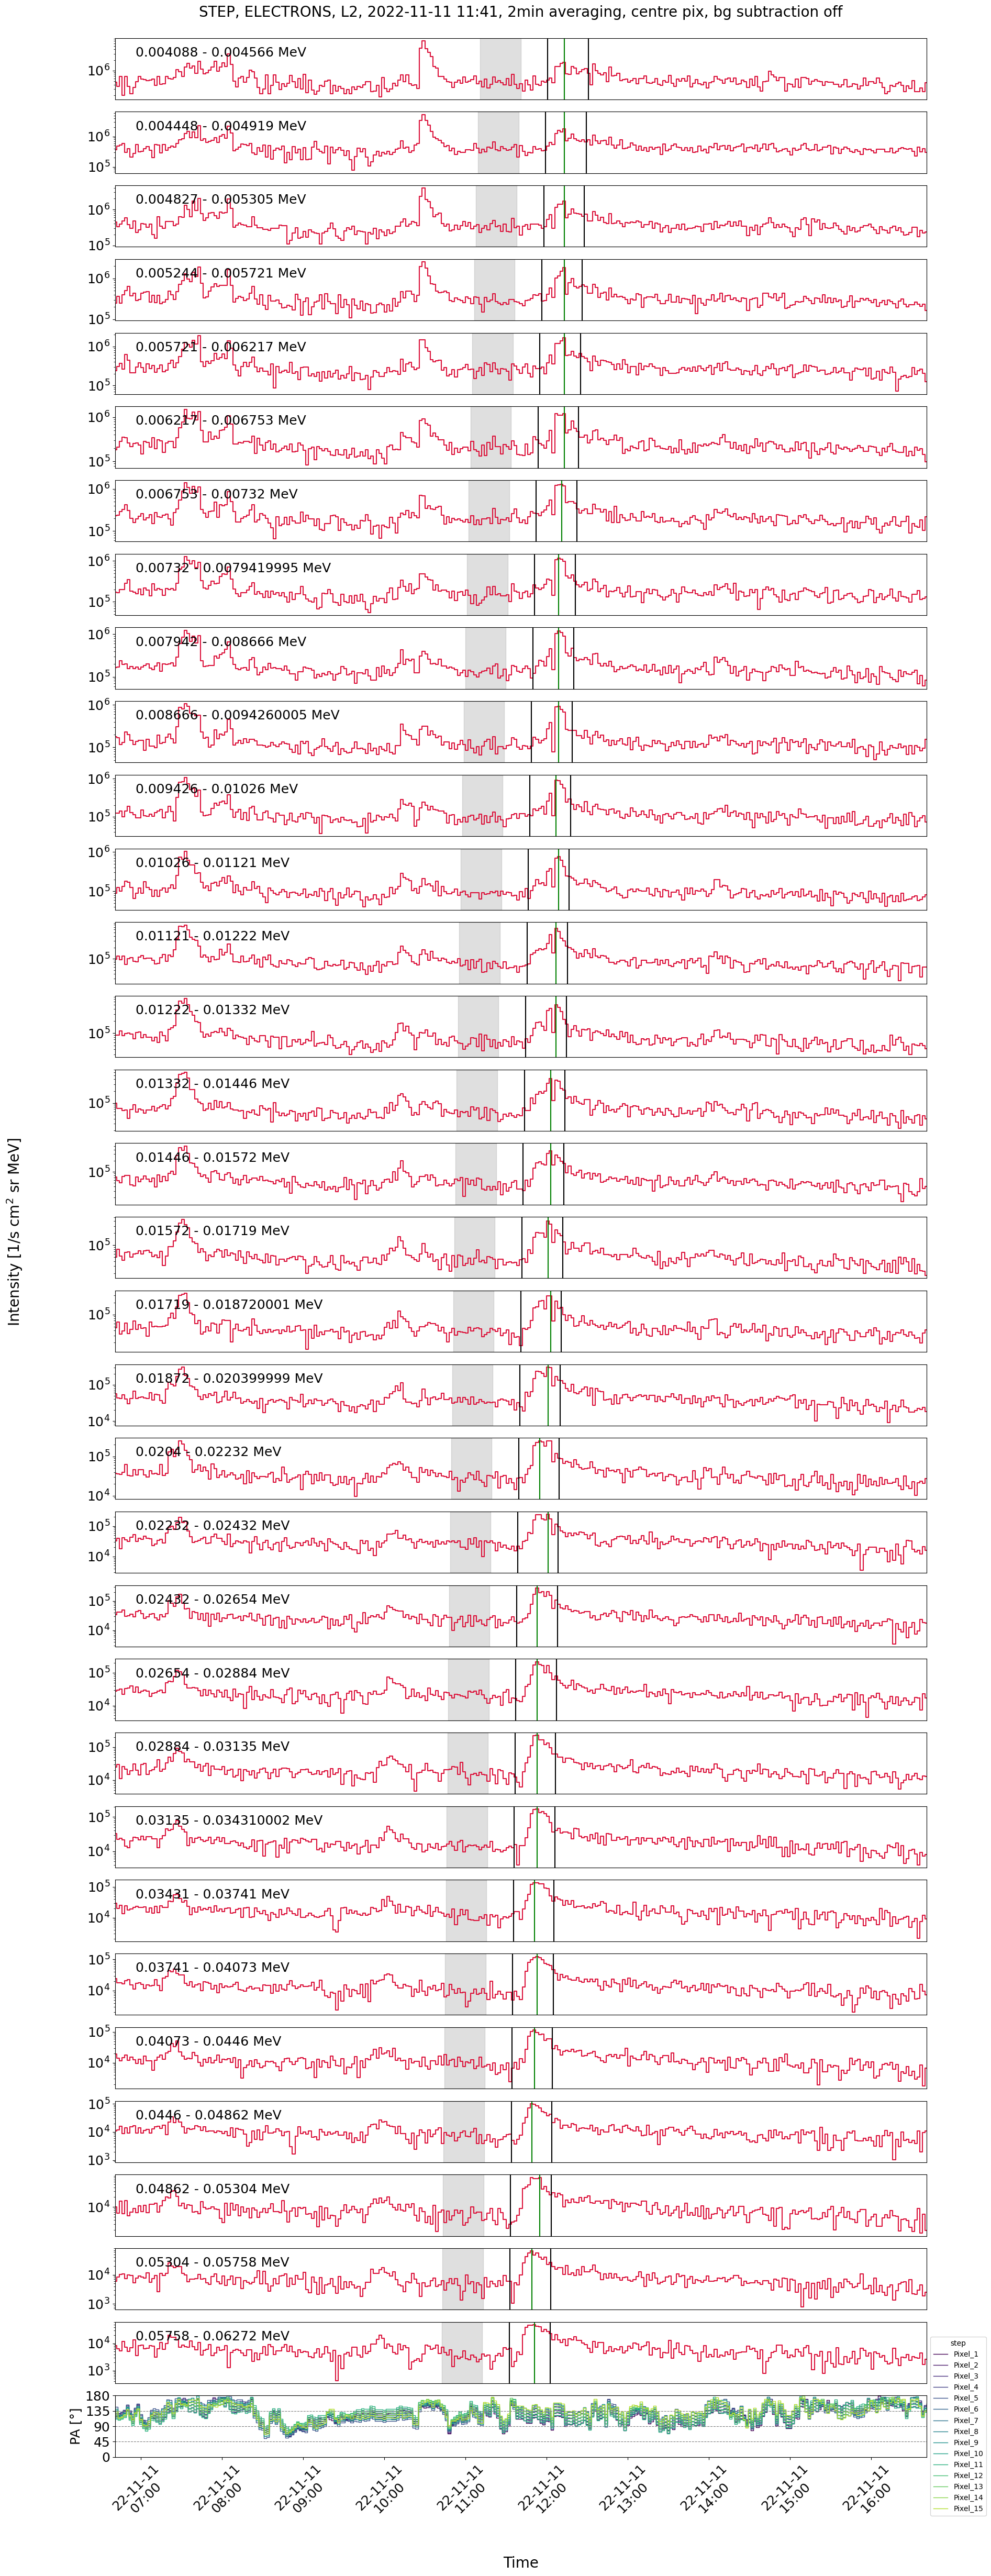

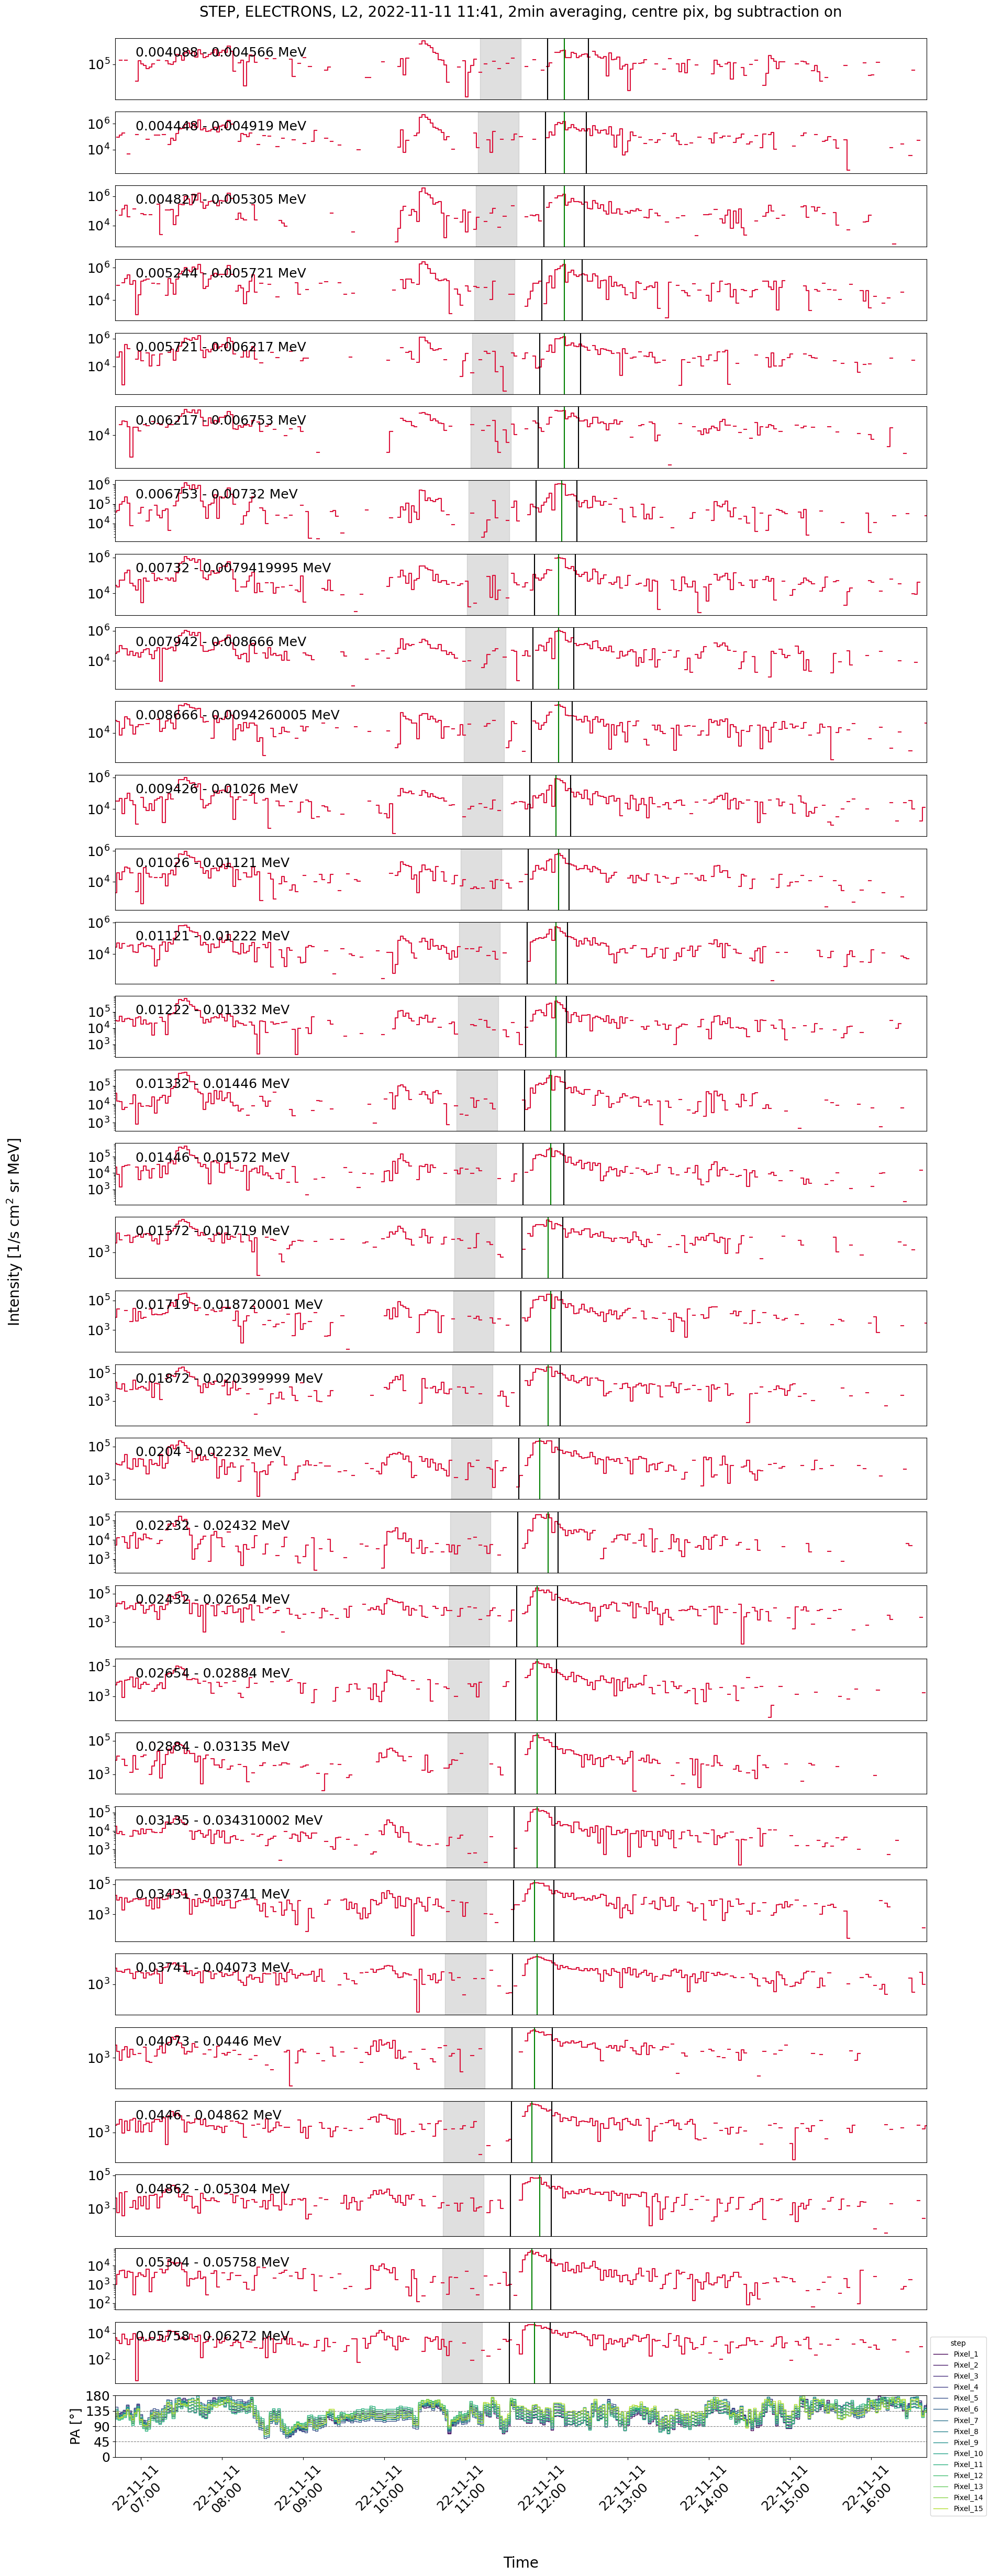

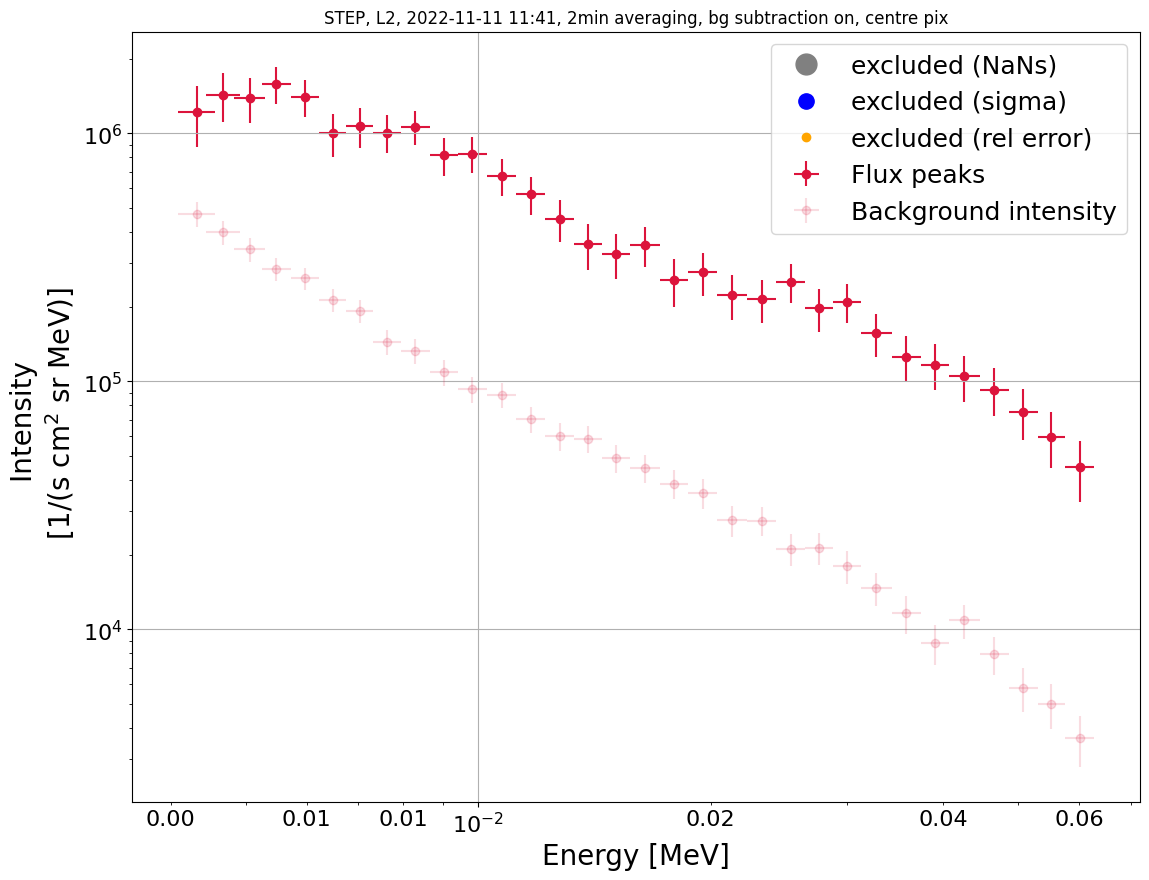

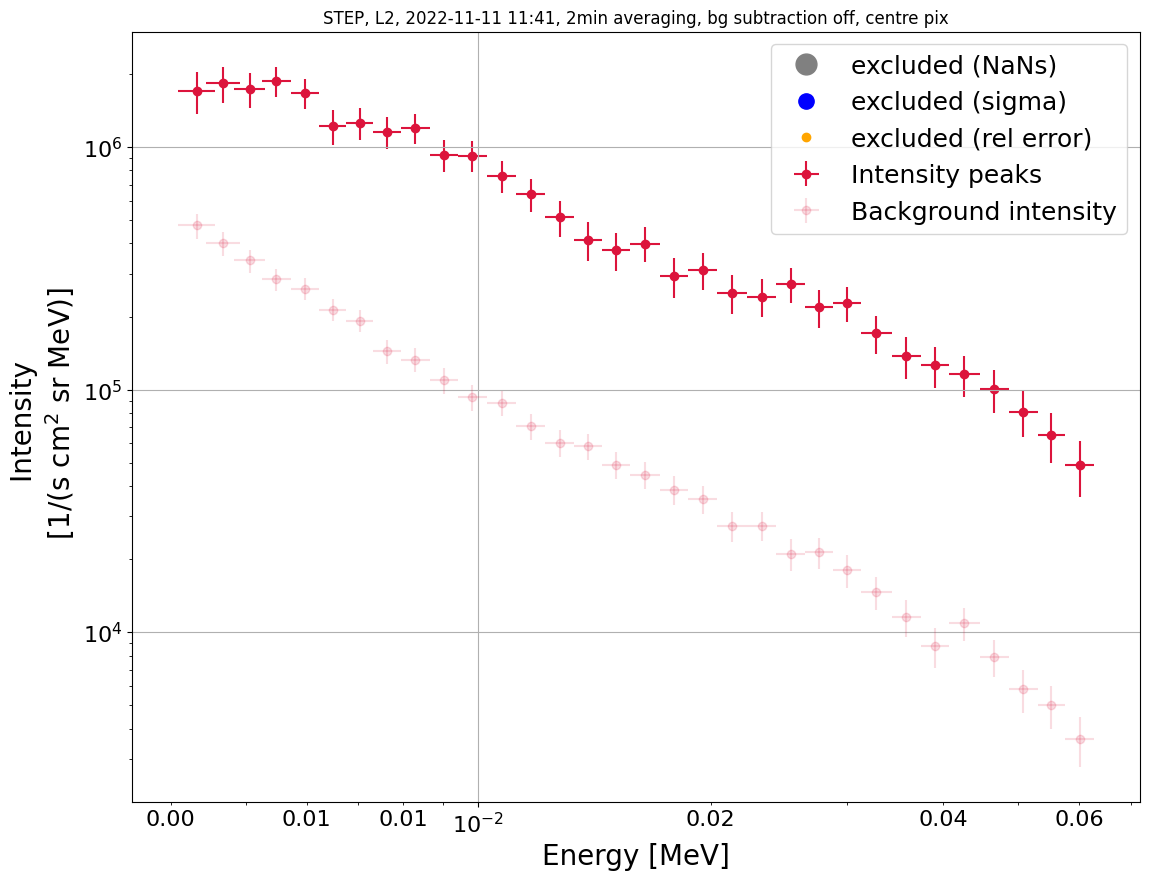

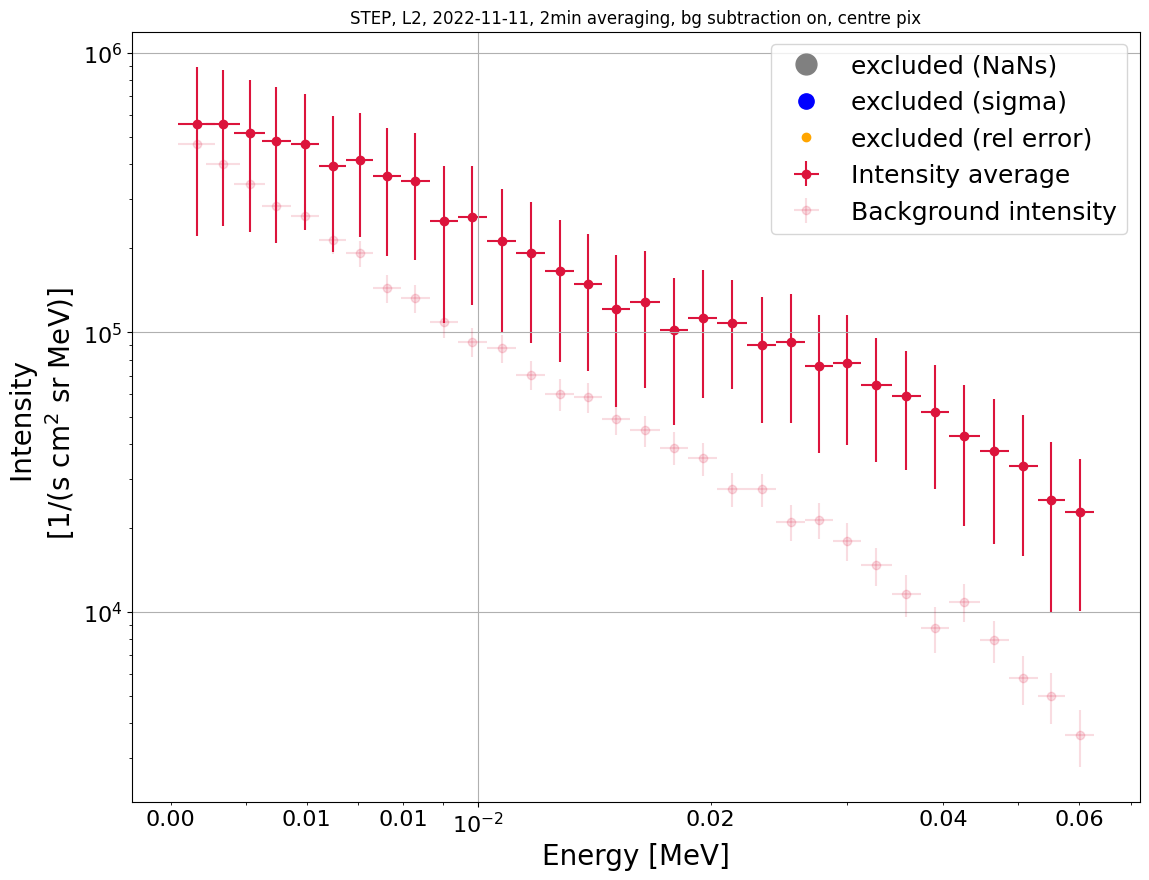

In [20]:
#JUST RUN
centre_pix = True
if step and pixels:
    data_step_pix = extract_particle_data(df_particles_step_pix, energies_step, plot_start, plot_end, t_inj, 
                                      bgstart = bg_start , bgend = bg_end, bg_distance_from_window = bg_distance_from_window, 
                                      bg_period = bg_period, travel_distance = travel_distance, 
                                      travel_distance_second_slope = travel_distance_second_slope, fixed_window = fixed_window, 
                                      instrument = 'step', data_type = 'l2', averaging=averaging, 
                                      masking=False,  centre_pix = centre_pix, species = species)


    if saving: 
        write_to_csv(data_step_pix, date = date_string, path=path_to_folder, direction = direction, 
                     centre_pix = centre_pix, species = species)
        
    plot_channels(data_step_pix, bg_subtraction=False, path=plot_path, savefig=saving, plot_pa=plot_pa, 
                  coverage=coverage_step, sigma = sigma, frac_nan_threshold = frac_nan_threshold, 
                  rel_err_threshold = rel_err, centre_pix = centre_pix, date = date, size = 20, species = species)
    
    bg_b = bg_subtraction
    plot_channels(data_step_pix, bg_subtraction=bg_b, path=plot_path, savefig=saving, plot_pa=plot_pa, 
                  coverage=coverage_step, sigma = sigma, frac_nan_threshold = frac_nan_threshold, 
                  rel_err_threshold = rel_err, centre_pix = centre_pix, date = date, size = 20, species = species)
    
    bg_b = bg_subtraction
    plot_spectrum_peak(data_step_pix, bg_subtraction=bg_b, path=plot_path, savefig=saving, sigma = sigma, 
                       frac_nan_threshold = frac_nan_threshold, rel_err_threshold= rel_err, direction = direction, 
                       centre_pix = centre_pix, date = date, species = species)
    
    plot_spectrum_peak(data_step_pix, bg_subtraction=False, path=plot_path, savefig=saving, sigma = sigma, 
                       frac_nan_threshold = frac_nan_threshold, rel_err_threshold= rel_err, direction = direction, 
                       centre_pix = centre_pix, date = date, species = species)

    plot_spectrum_average(data_step_pix, species, bg_b, saving, plot_path, sigma=sigma, 
                          frac_nan_threshold=frac_nan_threshold, rel_err_threshold=rel_err, 
                          direction=direction, centre_pix=centre_pix)
    
 

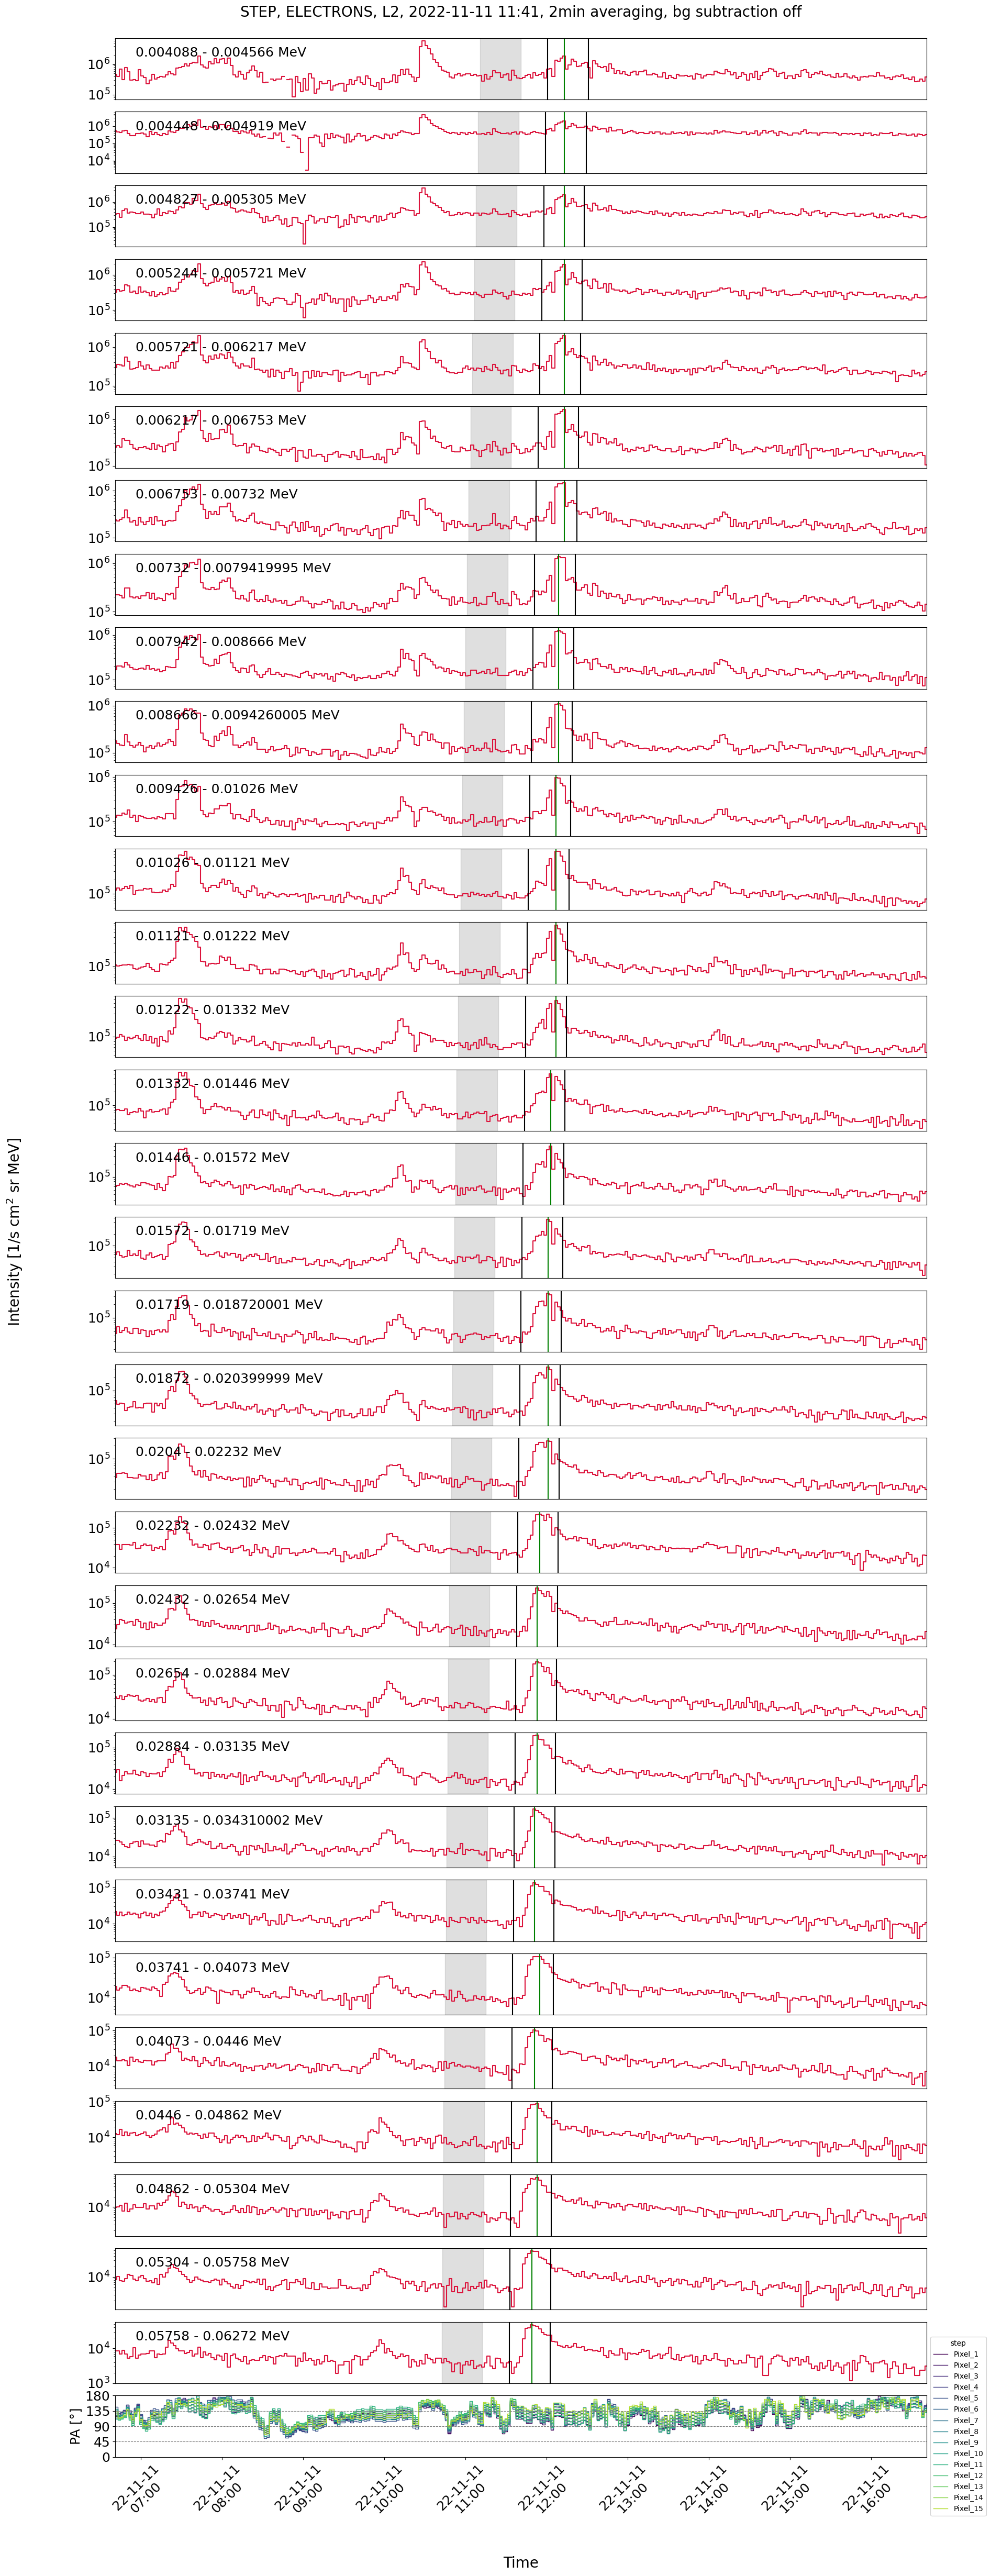

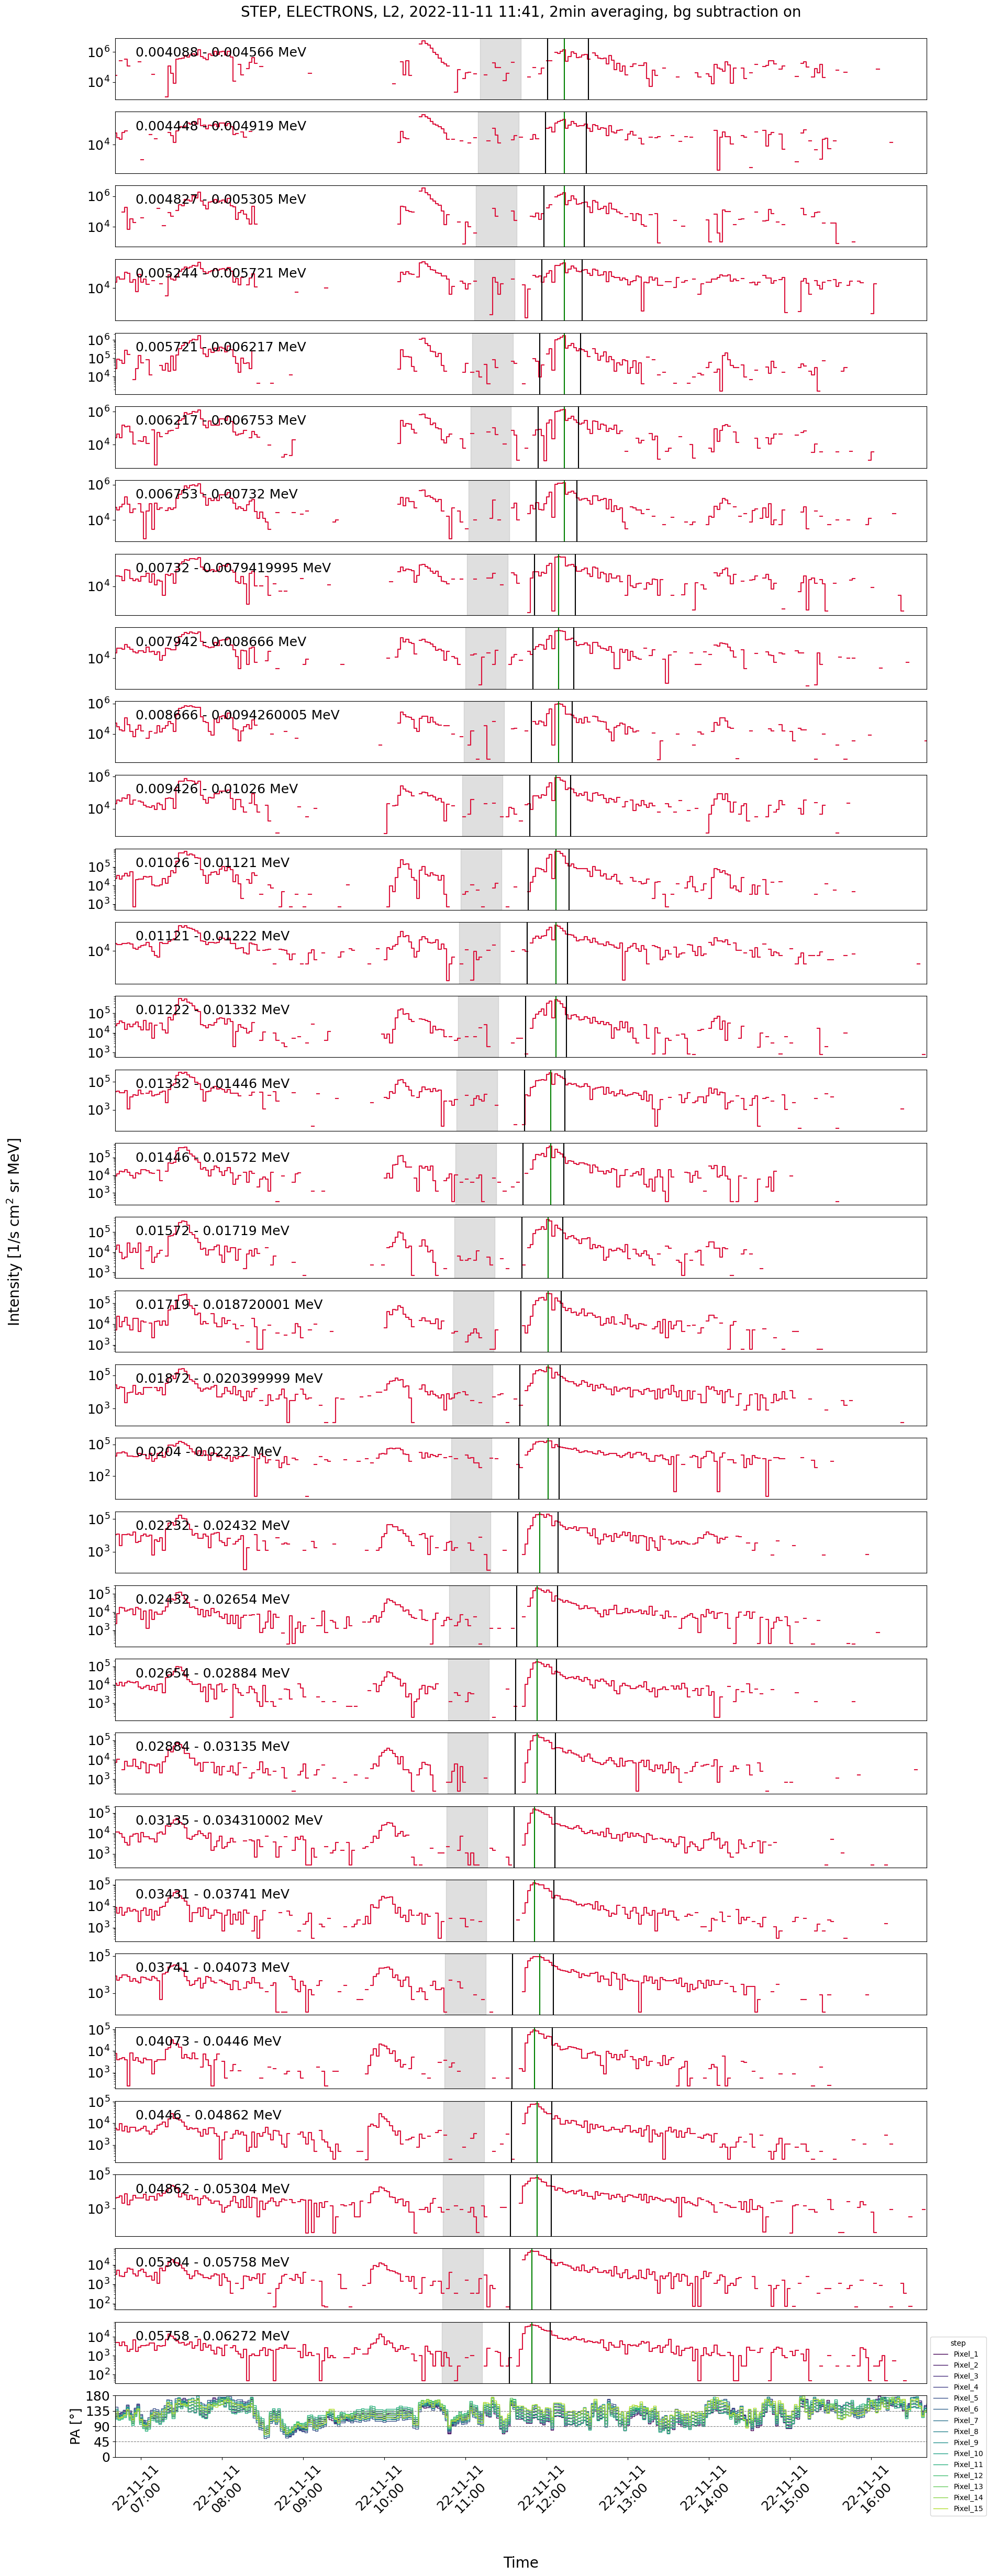

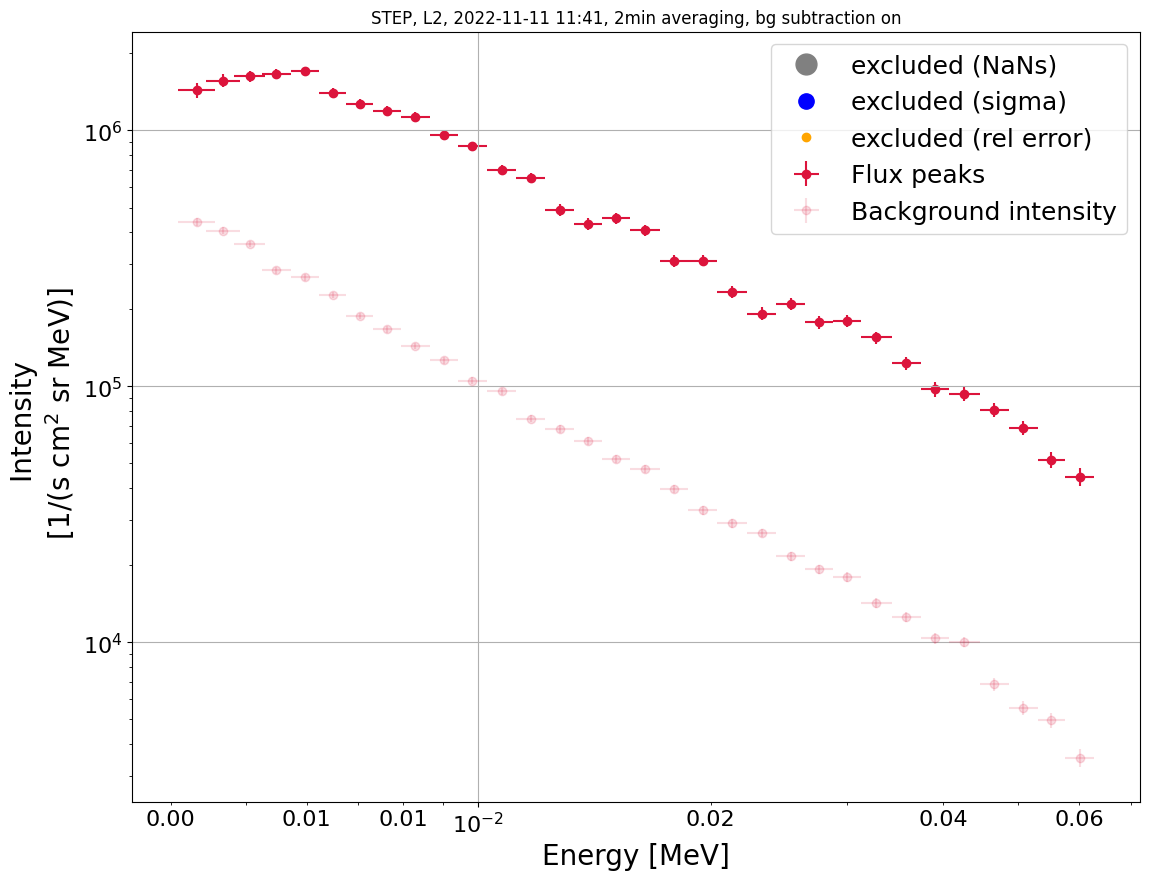

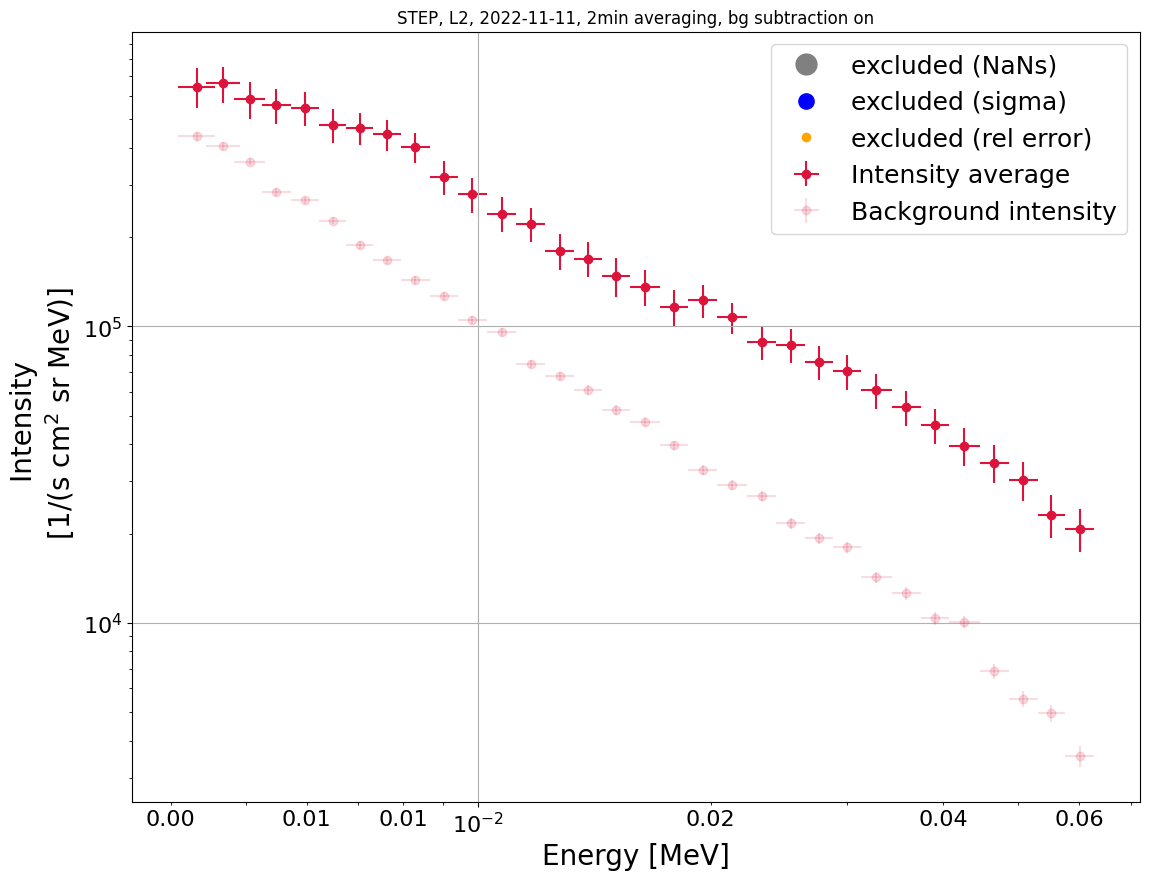

In [21]:
#JUST RUN
centre_pix = False
if step:  
    data_step = extract_particle_data(df_particles_step, energies_step, plot_start, plot_end, t_inj, 
                                      bgstart = bg_start , bgend = bg_end, bg_distance_from_window = bg_distance_from_window, 
                                      bg_period = bg_period, travel_distance = travel_distance, 
                                      travel_distance_second_slope = travel_distance_second_slope, fixed_window = fixed_window, 
                                      instrument = 'step', data_type = 'l2', averaging=averaging, 
                                      masking=False,  centre_pix = centre_pix, species = species)

    if saving: 
        write_to_csv(data_step, date = date_string, path=path_to_folder, direction = direction, species = species)
        
    plot_channels(data_step, bg_subtraction=False, path=plot_path, savefig=saving, plot_pa=plot_pa, 
                  coverage=coverage_step, sigma = sigma, frac_nan_threshold = frac_nan_threshold, 
                  rel_err_threshold = rel_err, centre_pix = centre_pix, date = date , size = 20, species = species)
    
    bg_b = bg_subtraction
    plot_channels(data_step, bg_subtraction=bg_b, path=plot_path, savefig=saving, plot_pa=plot_pa, 
                  coverage=coverage_step, sigma = sigma, frac_nan_threshold = frac_nan_threshold, 
                  rel_err_threshold = rel_err, centre_pix = centre_pix, date = date, size = 20, species = species)
    
    bg_b = bg_subtraction
    plot_spectrum_peak(data_step, bg_subtraction=bg_b, path=plot_path, savefig=saving, sigma = sigma, 
                       frac_nan_threshold = frac_nan_threshold, rel_err_threshold= rel_err, direction = direction, 
                       centre_pix = centre_pix, date = date, species = species)
    
    plot_spectrum_average(data_step, species, bg_b, saving, plot_path, sigma=sigma, 
                          frac_nan_threshold=frac_nan_threshold, rel_err_threshold=rel_err, 
                          direction=direction, centre_pix=centre_pix)
    
 


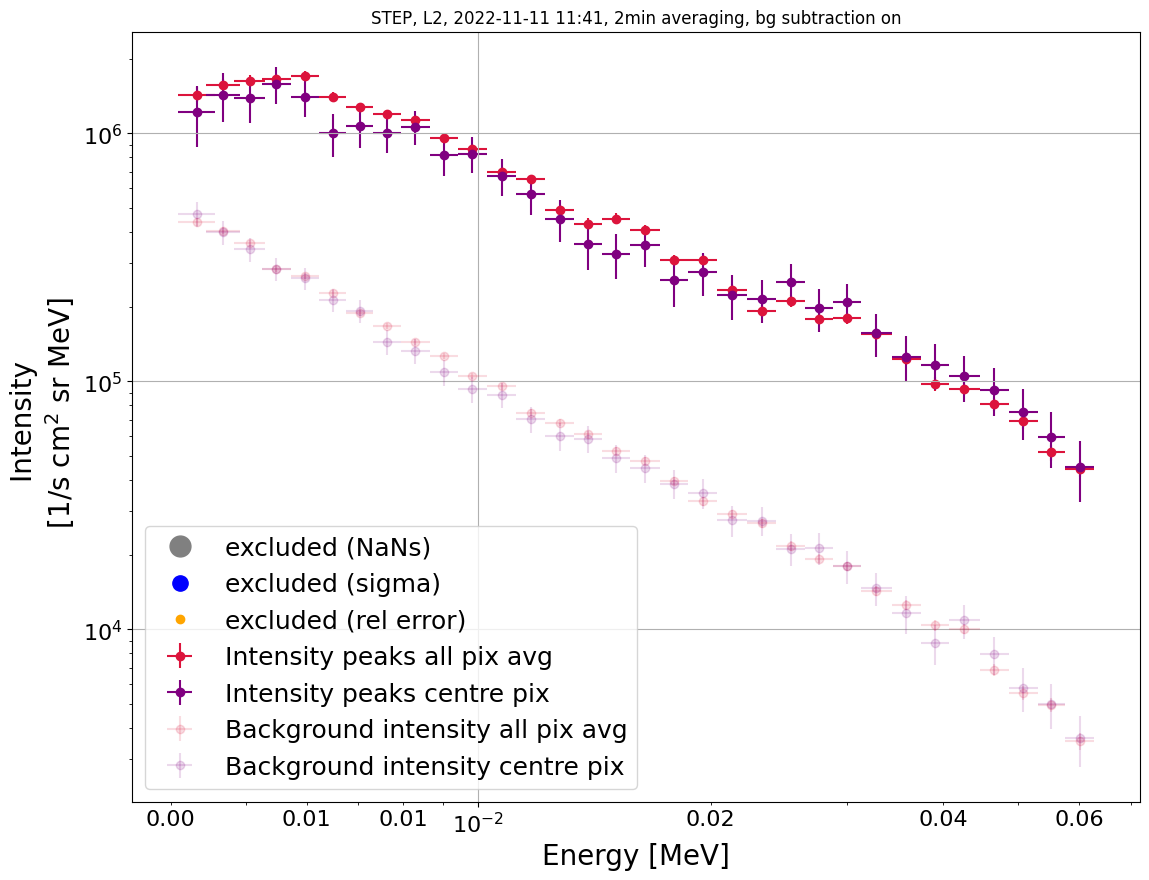

In [22]:
#JUST RUN
if pixels and step:
    centre_pix_average_comparison_spec(data_step, data_step_pix, bg_subtraction=bg_b, path=plot_path, savefig=saving, sigma = sigma, frac_nan_threshold = frac_nan_threshold, rel_err_threshold= rel_err,  date = date)
    

## EPT

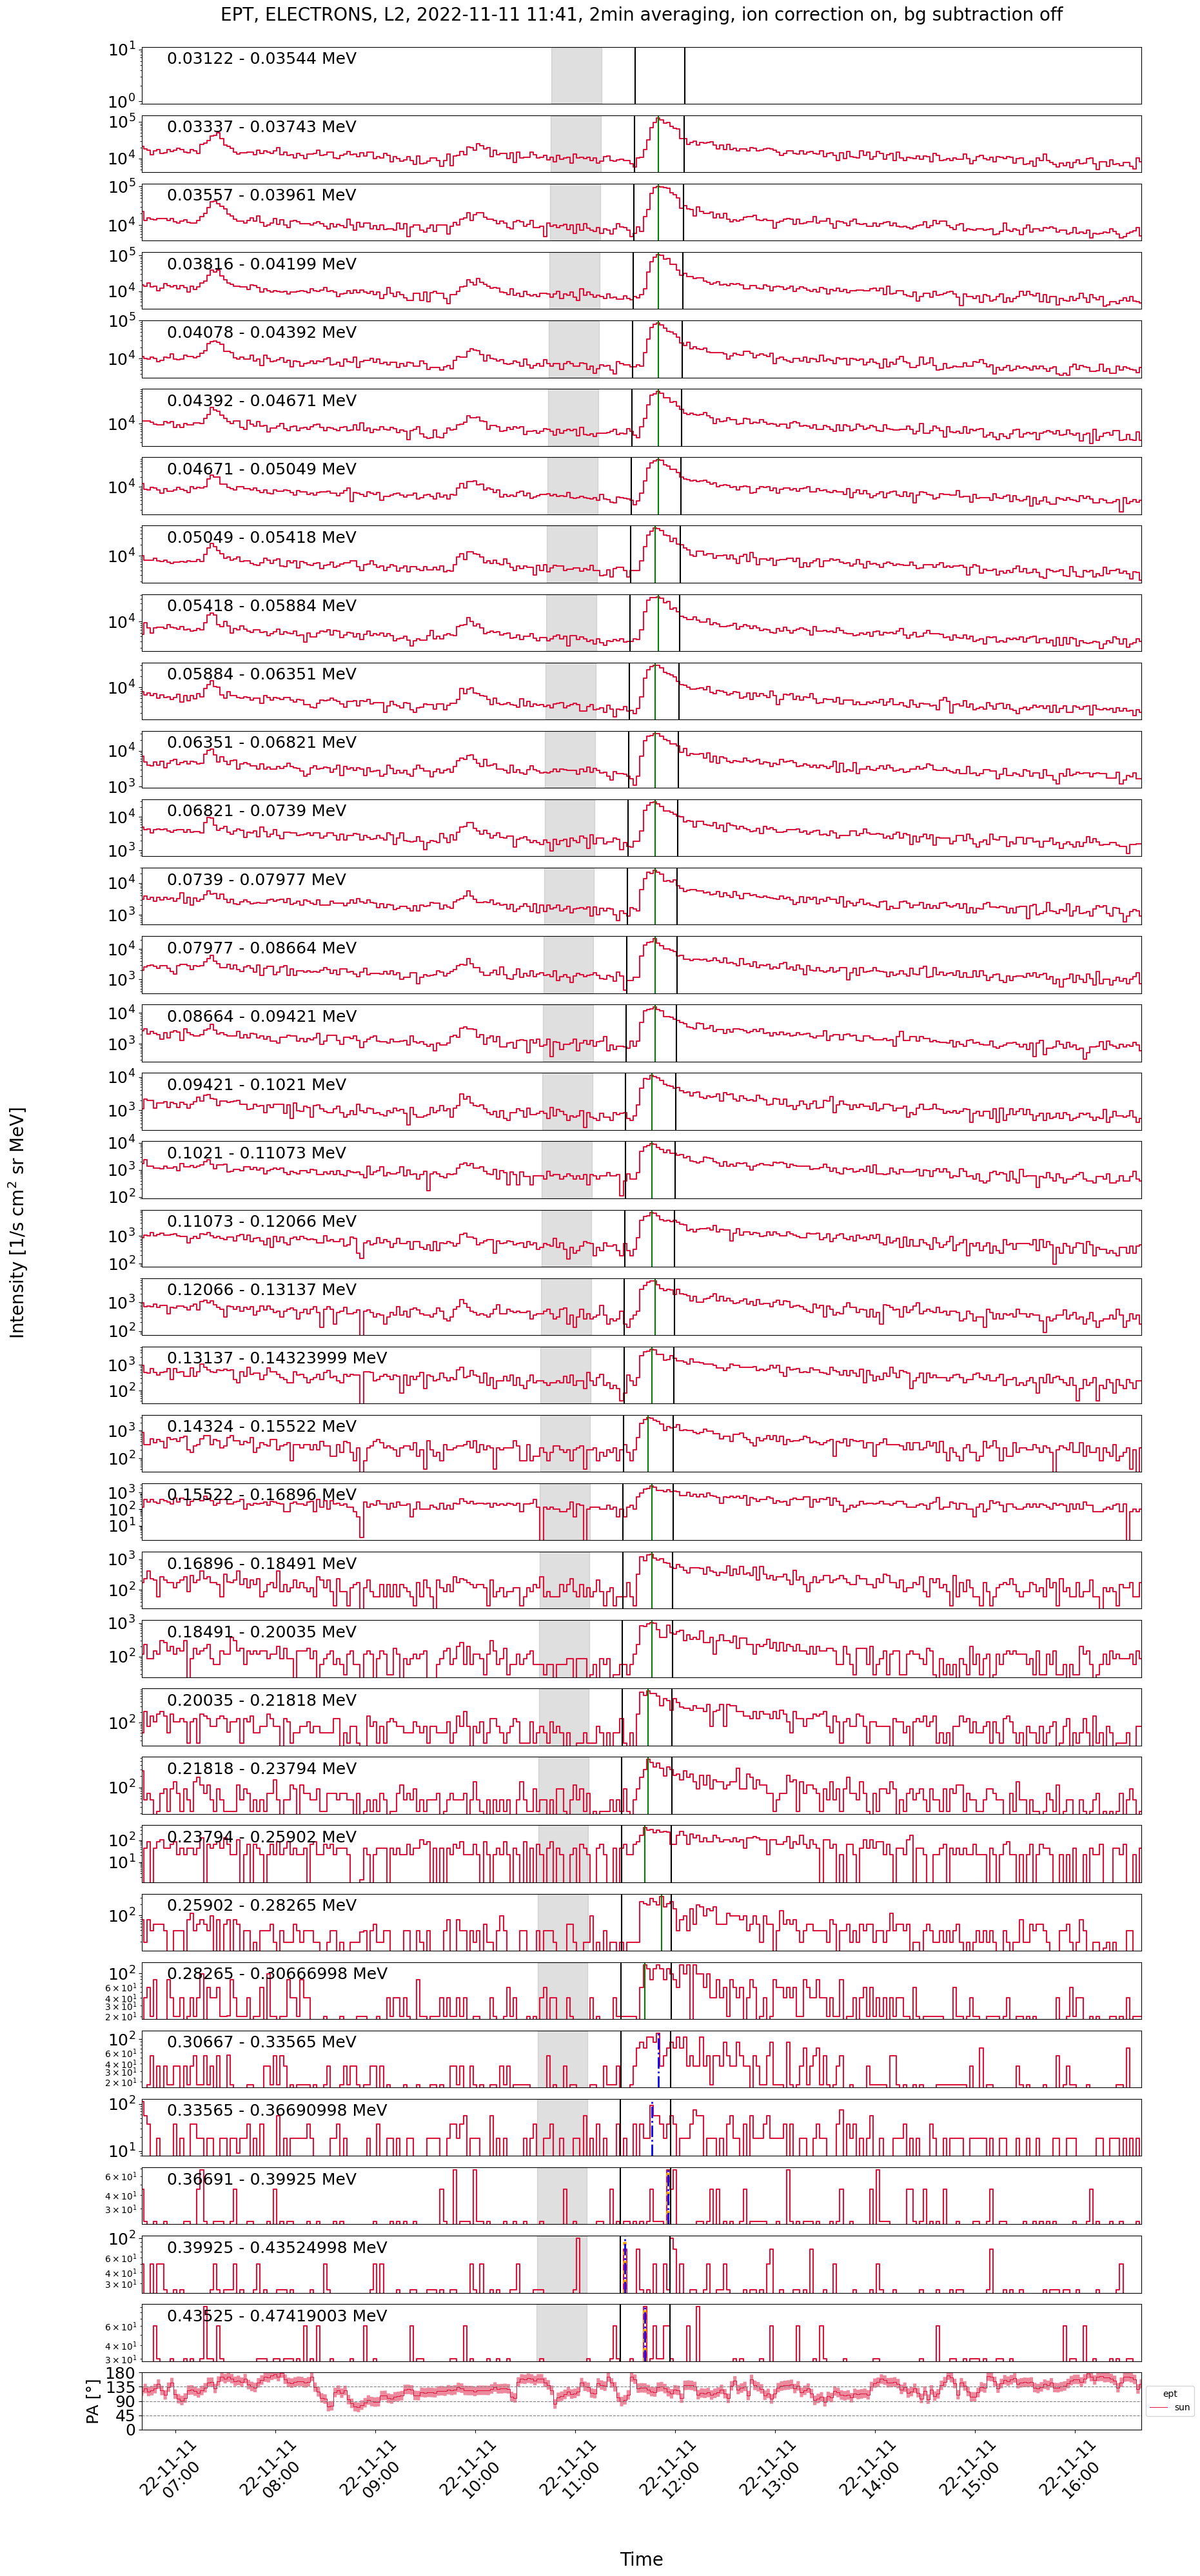

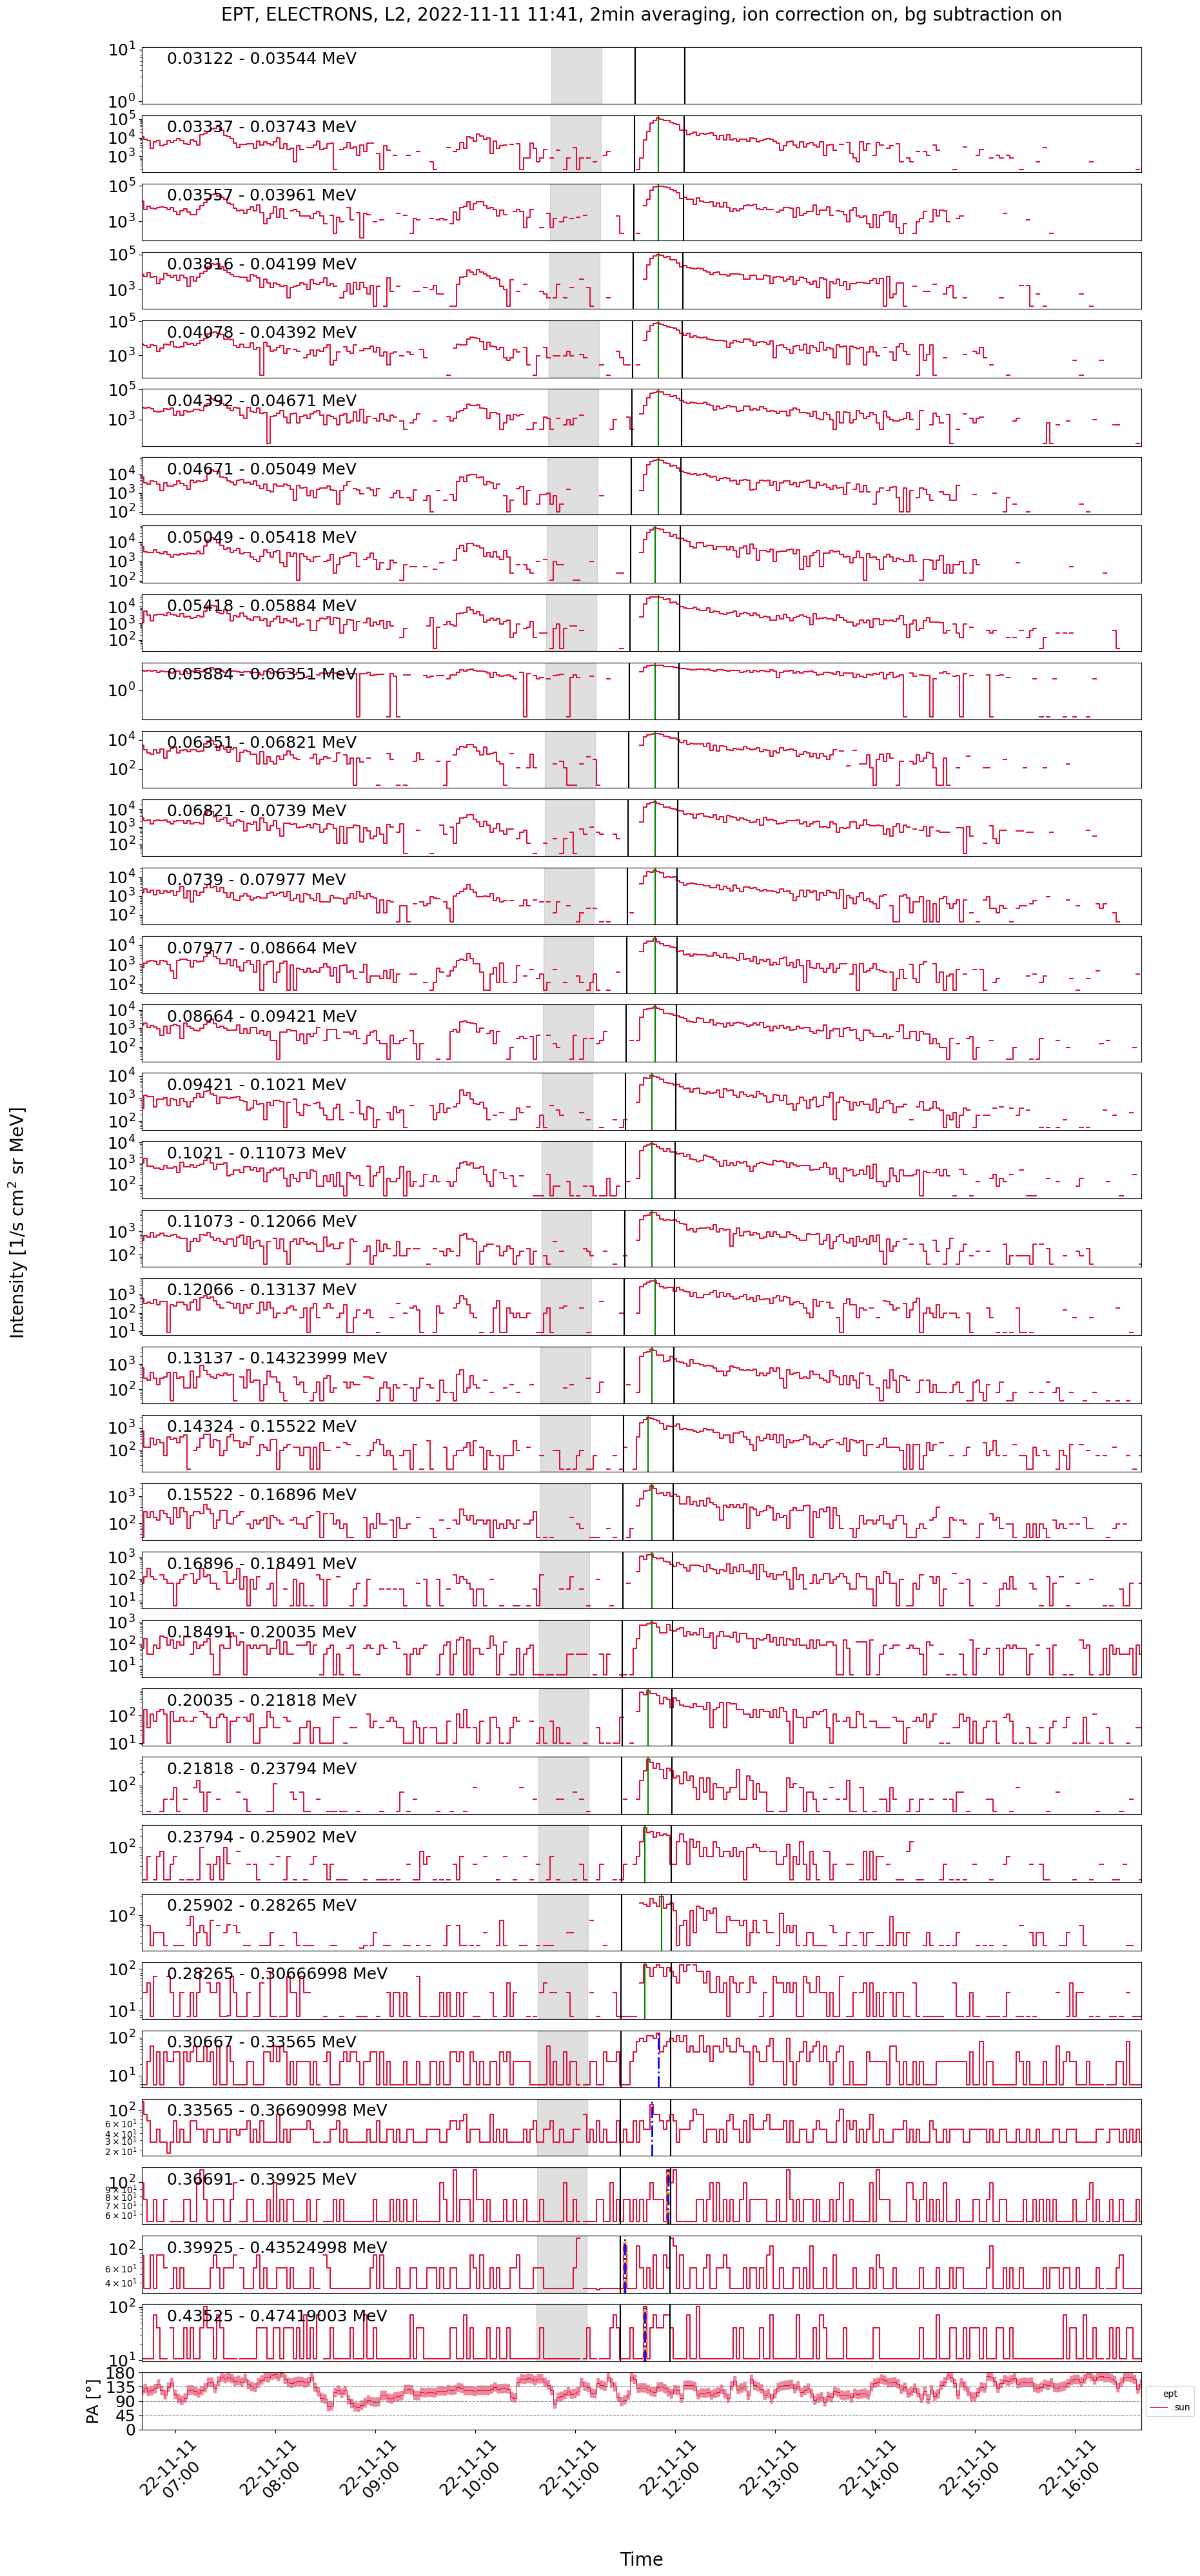

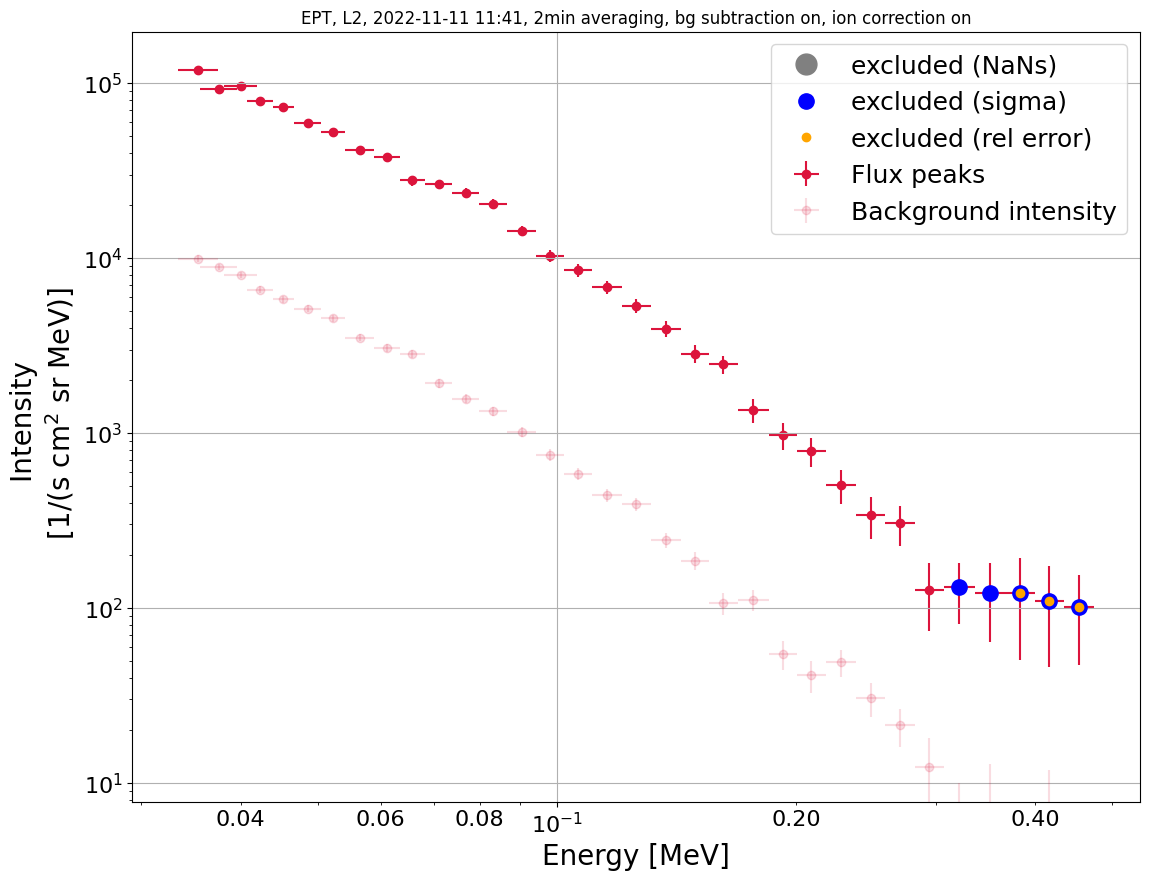

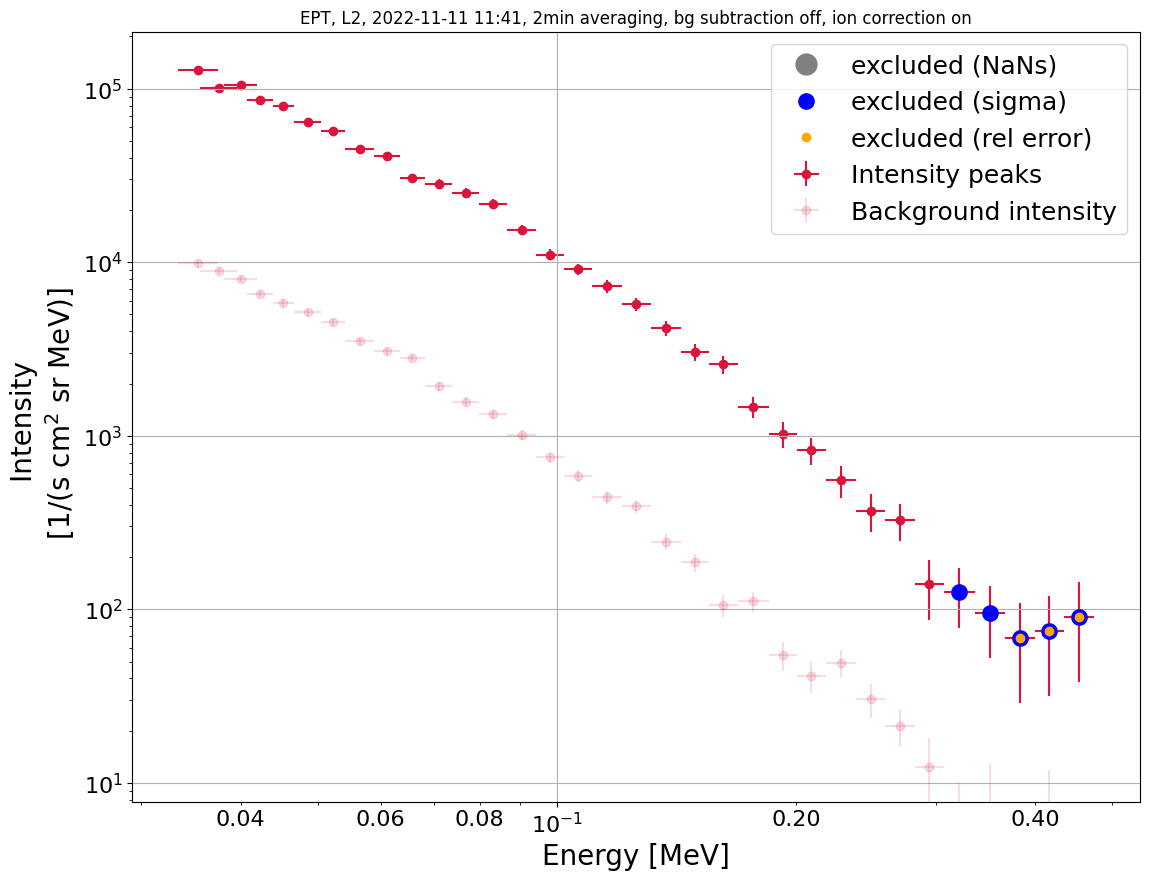

In [23]:
# JUST RUN
if ept:
    ion_b = ion_correction    
    data_ept = extract_particle_data(df_electrons_ept, energies_ept, plot_start, plot_end, t_inj, bgstart = bg_start, 
                                     bgend = bg_end, bg_distance_from_window = bg_distance_from_window, bg_period = bg_period, 
                                     travel_distance = travel_distance, travel_distance_second_slope=travel_distance_second_slope, 
                                     fixed_window=fixed_window, instrument = 'ept', data_type = 'l2', averaging=averaging, masking=True, 
                                     ion_conta_corr=ion_b, df_protons = df_protons_ept, species = species)

    
    

    if saving: write_to_csv(data_ept, date = date_string, path=path_to_folder, direction = direction, species = species)
    plot_channels(data_ept, bg_subtraction=False, path=plot_path, savefig=saving, plot_pa=plot_pa, 
                  coverage=coverage_ept, sigma = sigma, frac_nan_threshold = frac_nan_threshold, 
                  rel_err_threshold = rel_err, viewing = direction, date = date, species = species, size = 20)
    bg_b = bg_subtraction
    plot_channels(data_ept, bg_subtraction=bg_b, path=plot_path, savefig=saving, plot_pa=plot_pa, 
                  coverage=coverage_ept, sigma = sigma, frac_nan_threshold = frac_nan_threshold, 
                  rel_err_threshold = rel_err, viewing = direction, date = date, species = species, size = 20)
    bg_b = bg_subtraction
    plot_spectrum_peak(data_ept, bg_subtraction=bg_b, path=plot_path, savefig=saving, sigma = sigma, 
                       frac_nan_threshold = frac_nan_threshold, rel_err_threshold = rel_err, 
                       direction = direction, date = date, species = species)
    plot_spectrum_peak(data_ept, bg_subtraction=False, path=plot_path, savefig=saving, sigma = sigma, 
                       frac_nan_threshold = frac_nan_threshold, rel_err_threshold = rel_err, 
                       direction = direction, date = date, species = species)
   
    #plot_spectrum_average(data_ept, bg_subtraction=bg_b, path=path_to_folder, savefig=saving, frac_nan_threshold=frac_nan_threshold)      


## HET

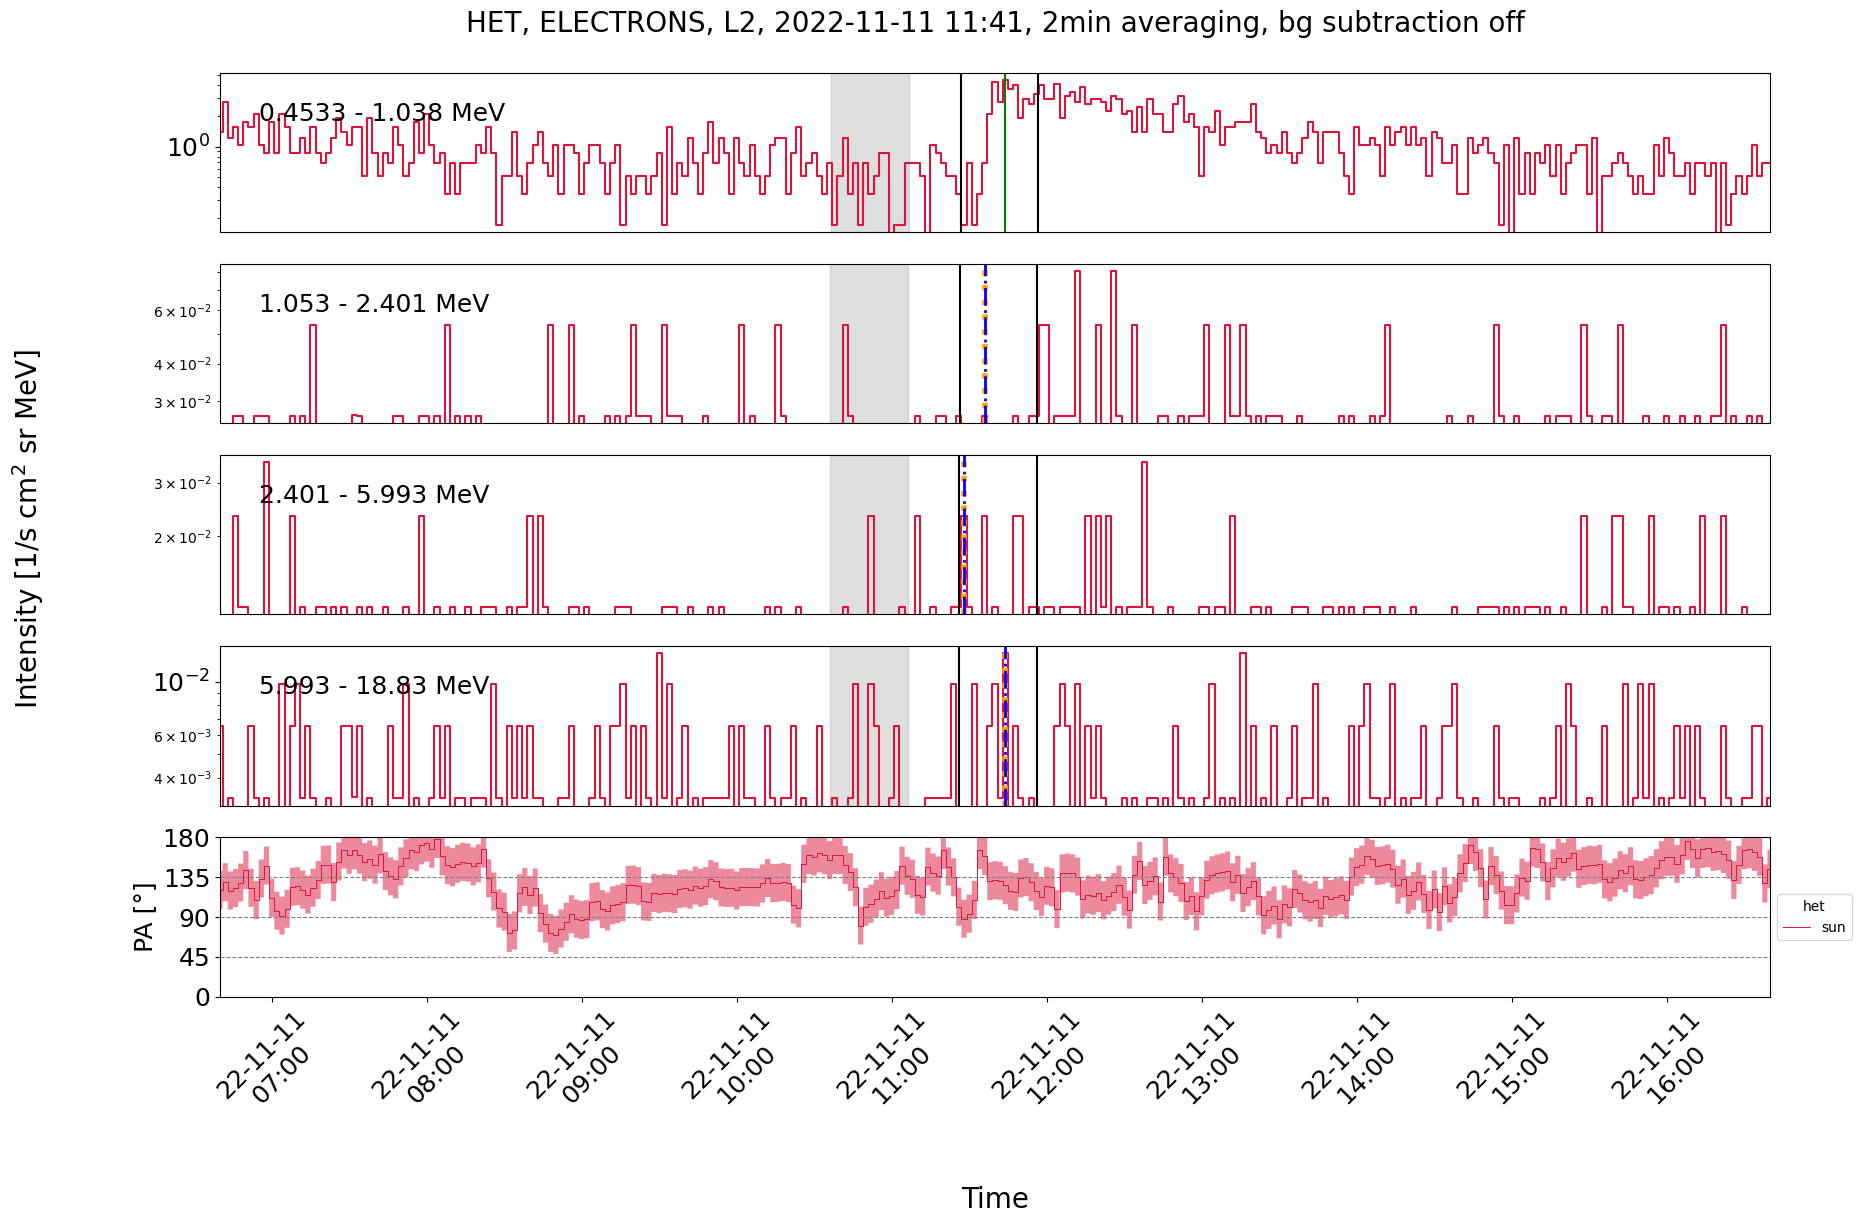

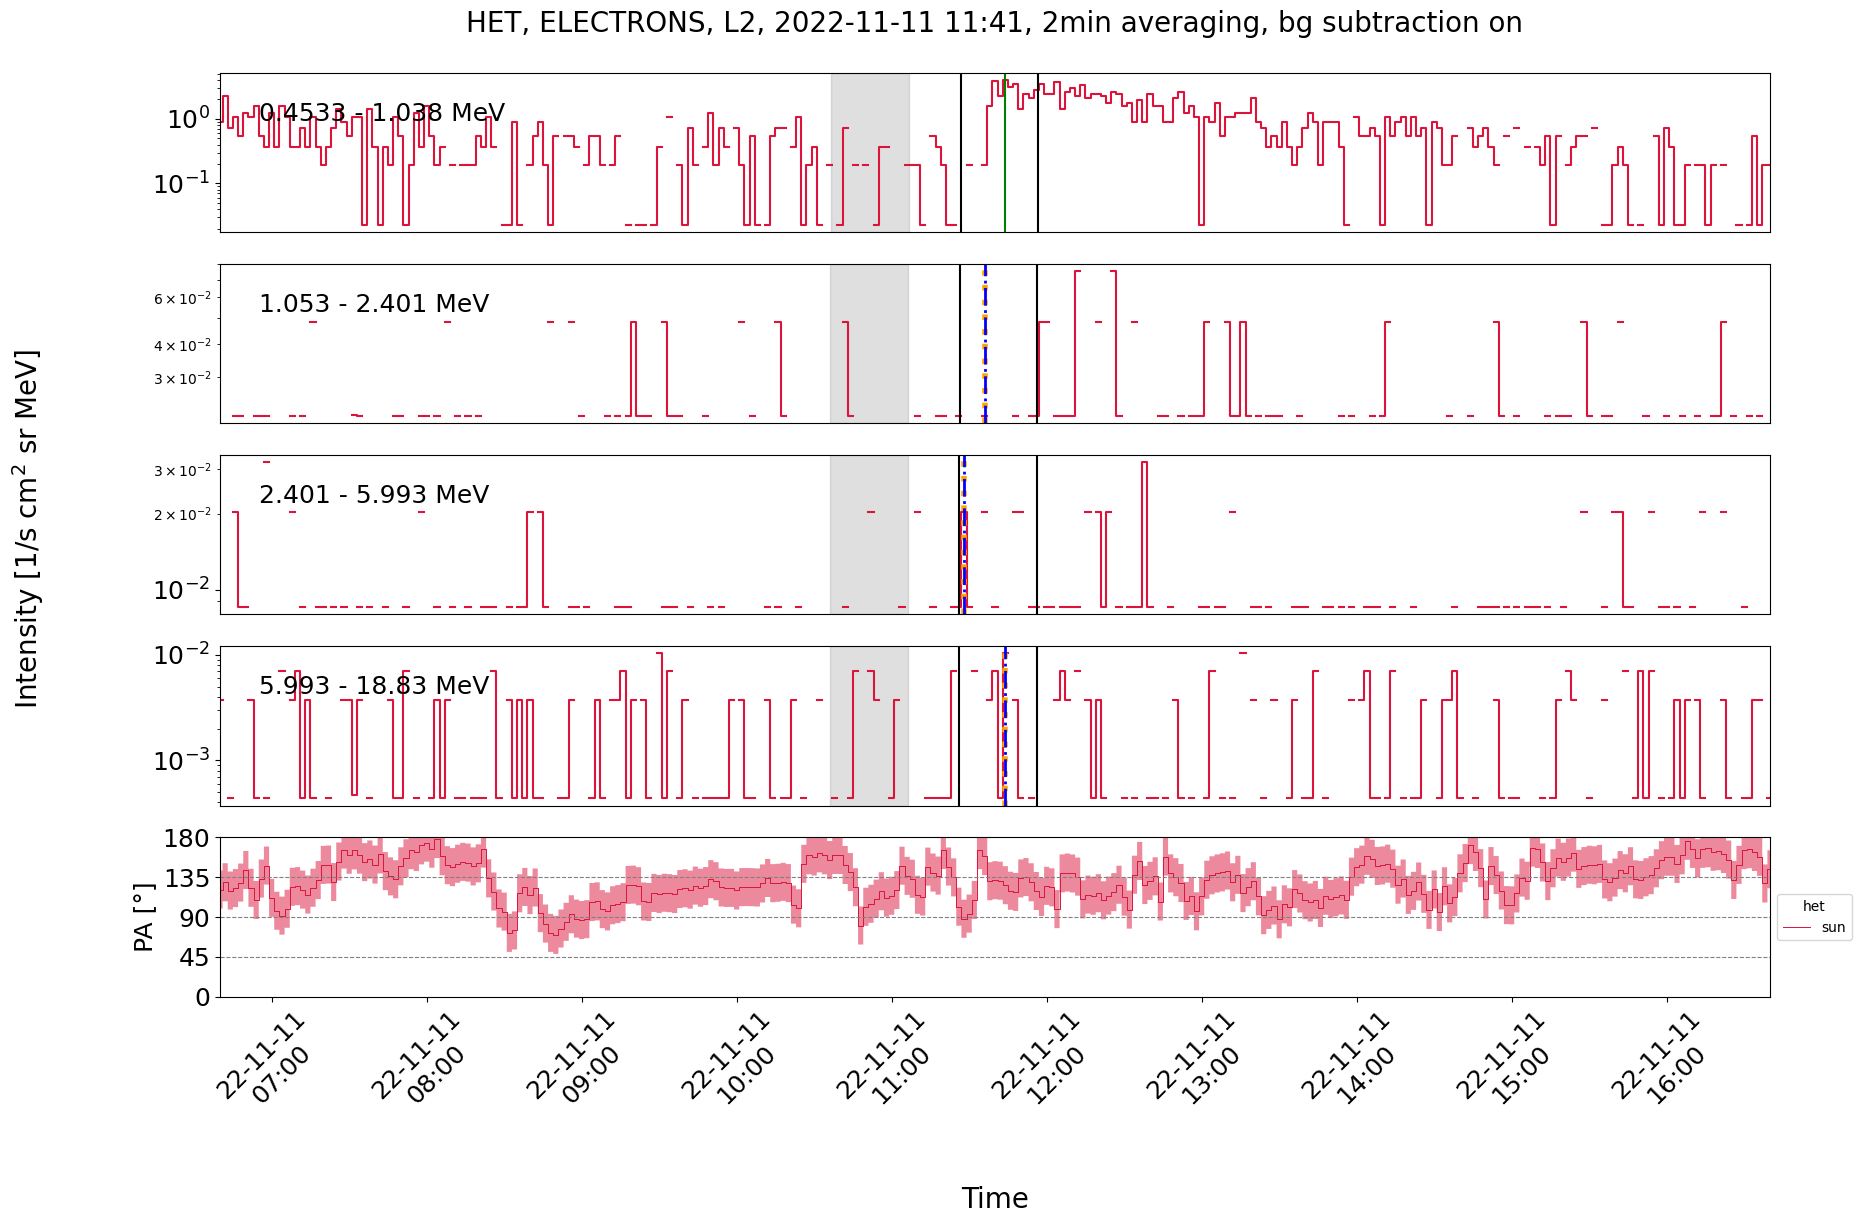

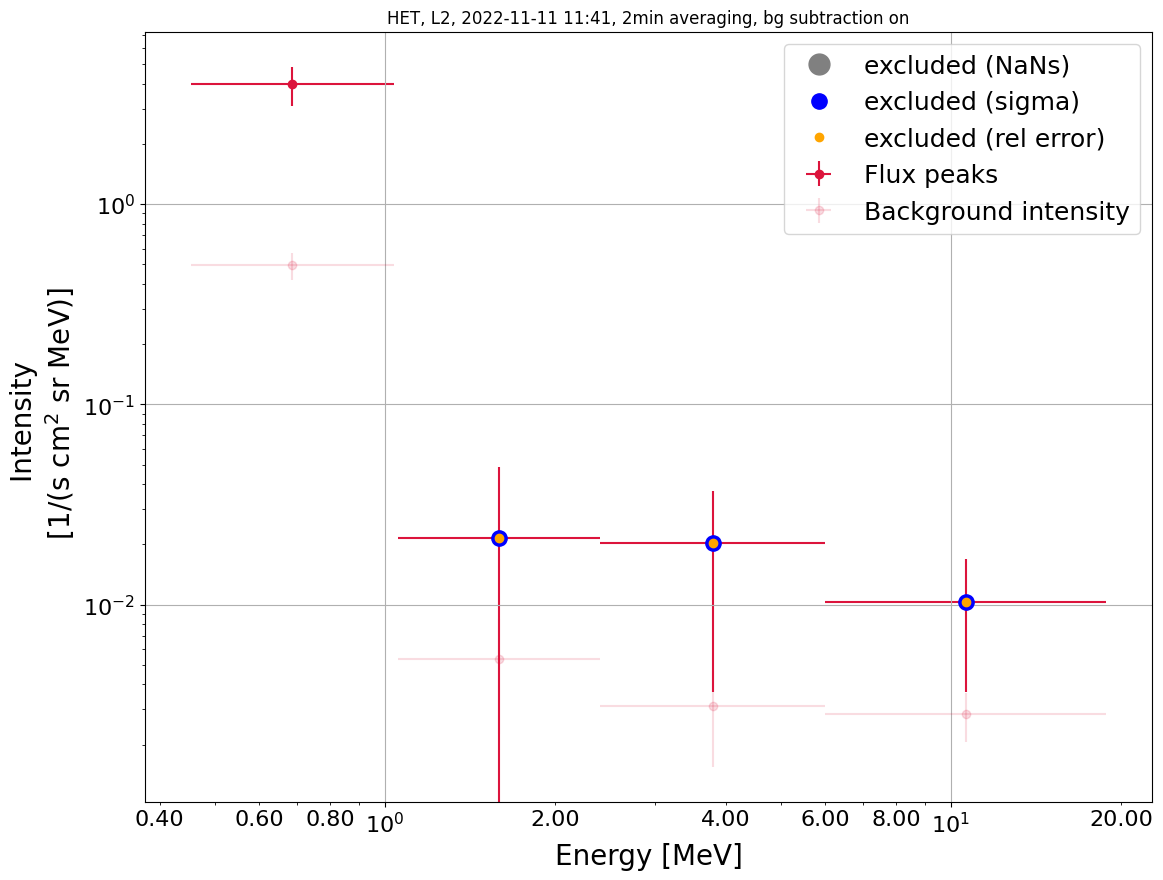

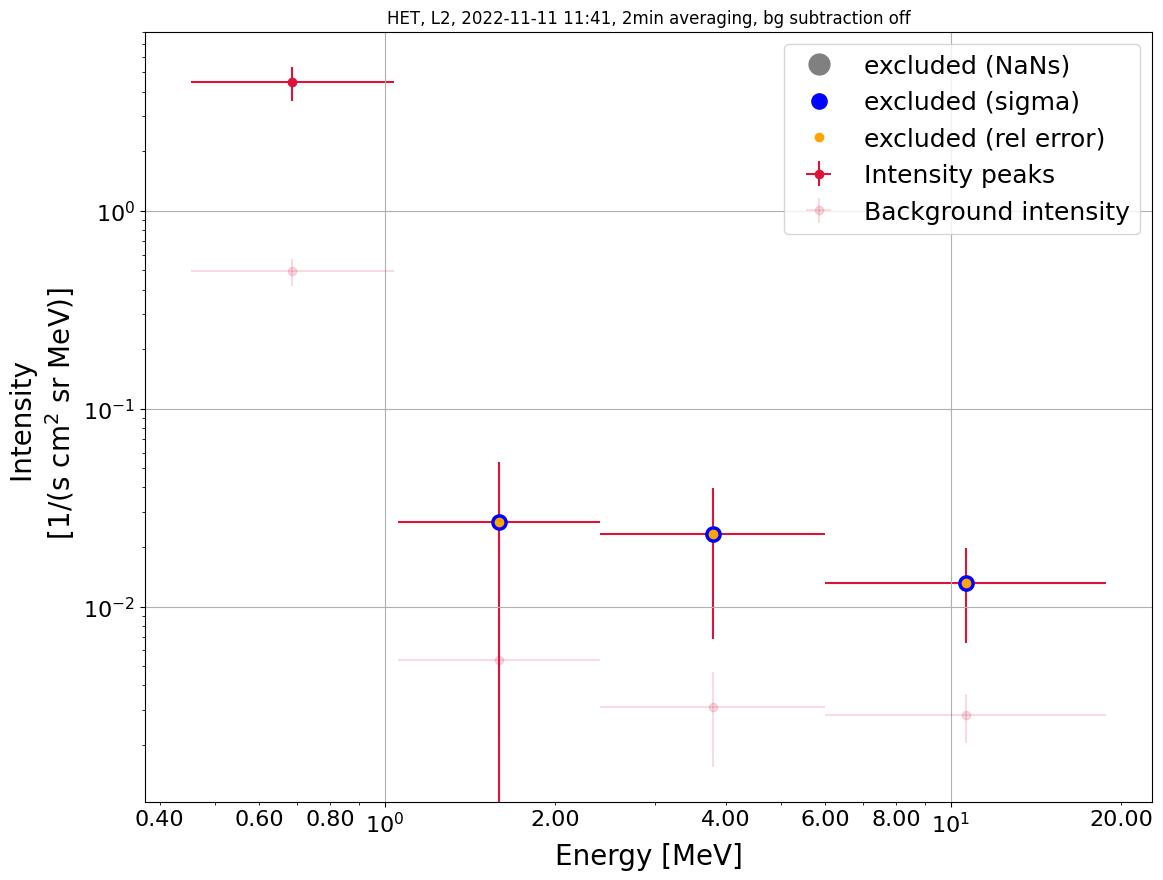

In [24]:
#JUST RUN 
if het:
    data_het = extract_particle_data(df_electrons_het, energies_het, plot_start, plot_end, t_inj, 
                                     bgstart = bg_start, bgend = bg_end,  bg_distance_from_window = bg_distance_from_window,
                                     bg_period = bg_period, travel_distance = travel_distance, 
                                     travel_distance_second_slope = travel_distance_second_slope, 
                                     fixed_window = fixed_window, instrument='het', data_type='l2', 
                                     averaging=averaging, df_protons = df_protons_het, species = species)

    if saving: write_to_csv(data_het, date = date_string, path=path_to_folder, direction = direction, species = species)
    plot_channels(data_het, bg_subtraction=False, path=plot_path, savefig=saving, plot_pa=plot_pa, 
                  coverage=coverage_het, sigma = sigma, frac_nan_threshold = frac_nan_threshold, 
                  rel_err_threshold = rel_err, viewing = direction, date = date, species = species, size = 20)
    bg_b = bg_subtraction
    plot_channels(data_het, bg_subtraction=bg_b, path=plot_path, savefig=saving, plot_pa=plot_pa, 
                  coverage=coverage_het, sigma = sigma, frac_nan_threshold = frac_nan_threshold, 
                  rel_err_threshold = rel_err, viewing = direction, date = date, species = species, size = 20)
    bg_b = bg_subtraction
    plot_spectrum_peak(data_het, bg_subtraction=bg_b, path=plot_path, savefig=saving, sigma = sigma, 
                       frac_nan_threshold = frac_nan_threshold, rel_err_threshold = rel_err, 
                       direction = direction, date = date, species = species)
    plot_spectrum_peak(data_het, bg_subtraction=False, path=plot_path, savefig=saving, sigma = sigma, 
                       frac_nan_threshold = frac_nan_threshold, rel_err_threshold = rel_err, 
                       direction = direction, date = date, species = species)



### Channels 

In [25]:
#JUST RUN
if pixels and step:
    print_channel(step = data_step_pix[1], ept = data_ept[1], het = data_het[1])

if step:
    print_channel(step = data_step[1], ept = data_ept[1], het = data_het[1])

if not step:
    print_channel(step = None, ept = data_ept[1], het = data_het[1])


STEP CHANNELS
 Channel  Primary Energy [MeV]
       0              0.004320
       1              0.004678
       2              0.005060
       3              0.005477
       4              0.005964
       5              0.006479
       6              0.007031
       7              0.007625
       8              0.008296
       9              0.009038
      10              0.009834
      11              0.010724
      12              0.011704
      13              0.012758
      14              0.013878
      15              0.015077
      16              0.016439
      17              0.017939
      18              0.019542
      19              0.021338
      20              0.023299
      21              0.025406
      22              0.027666
      23              0.030069
      24              0.032797
      25              0.035826
      26              0.039035
      27              0.042621
      28              0.046567
      29              0.050782
      30              0.

In [26]:
channels = [0, 3, 6,]

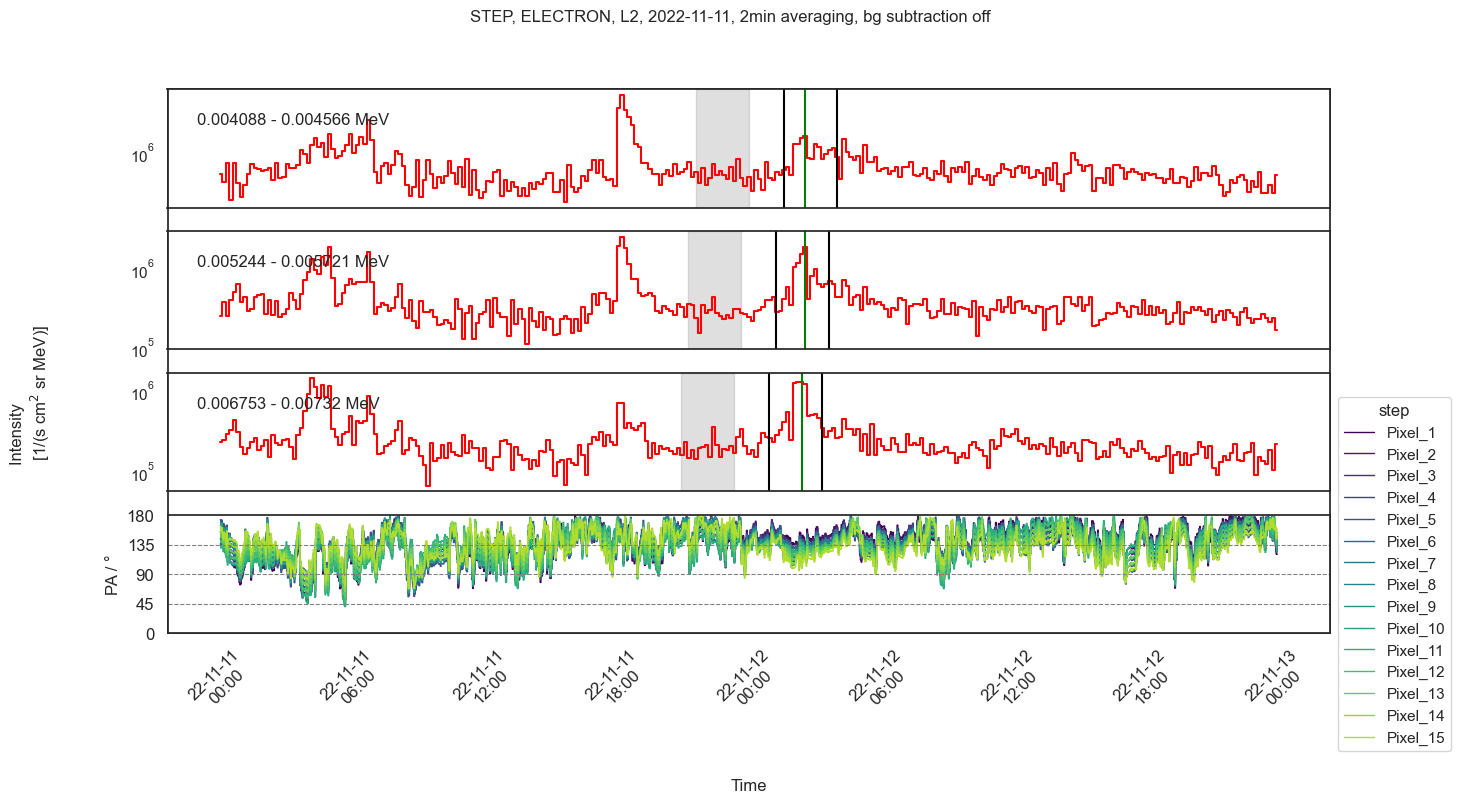

In [27]:
if step:
    plot_some_channels(
    data_step_pix,
    bg_subtraction=False,
    savefig=False,
    sigma=3,
    path=plot_path,
    key='',
    plot_pa=True,
    coverage=coverage_step,
    viewing='sun',
    frac_nan_threshold=0.9,
    rel_err_threshold=0.5,
    channels=channels,
    figsize_x=15,
    figsize_y=8,
    f_scale=1,
    f_size=12
)

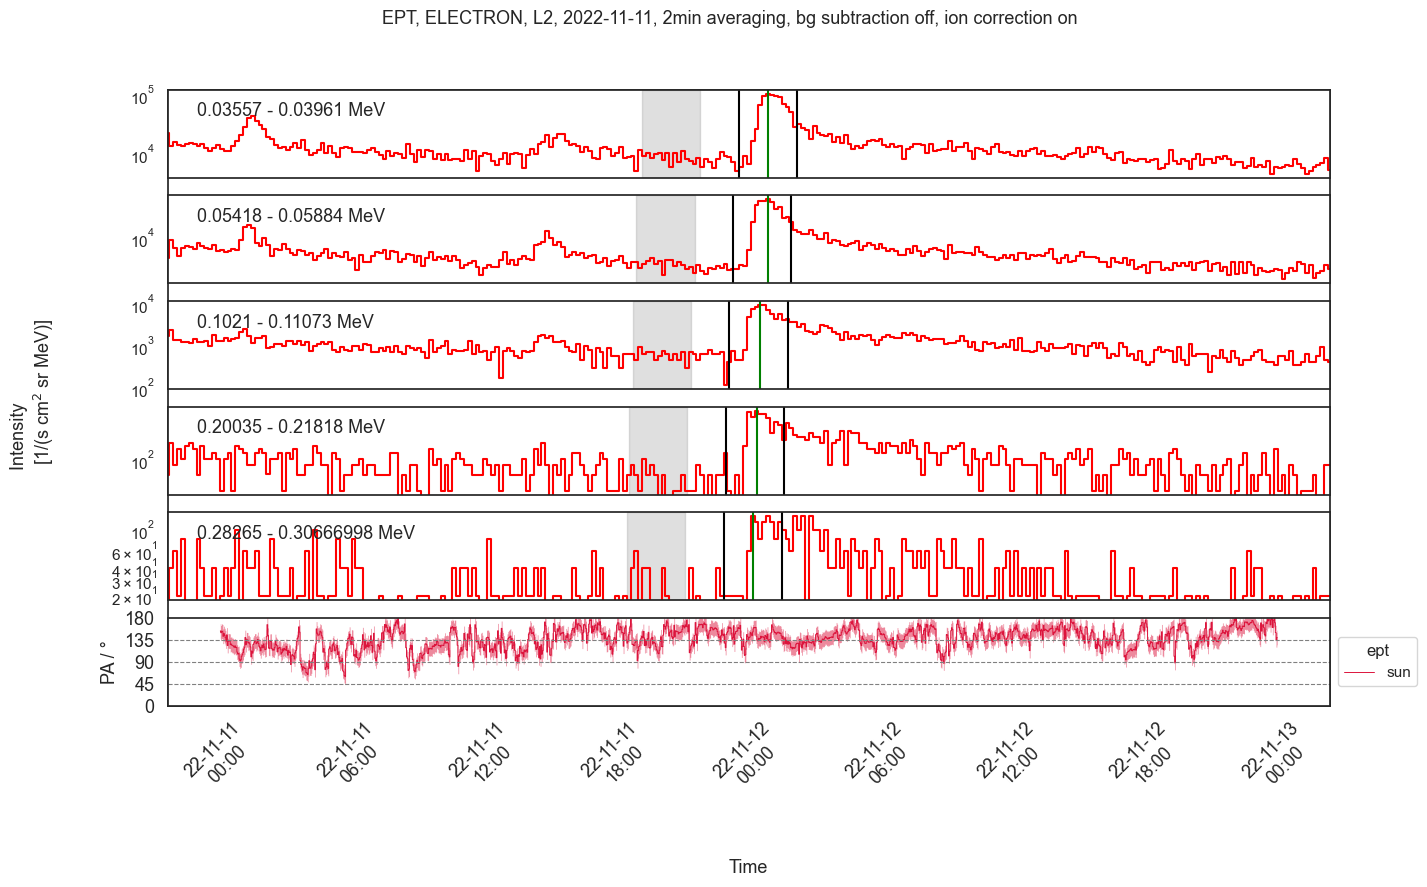

In [28]:
plot_some_channels(
    data_ept,
    bg_subtraction=False,
    savefig=False,
    sigma=3,
    path=plot_path,
    key='',
    plot_pa=True,
    coverage=coverage_ept,
    viewing='sun',
    frac_nan_threshold=0.9,
    rel_err_threshold=0.5,
    channels=[2, 8, 16, 24,28],
    figsize_x=15,
    figsize_y=8,
    f_scale=1,
    f_size=13
    
)

# Quality factors

``angle`` check the pitch angle panel in the timeseries plots. If the pitch angle is closer to 0, set ``angle`` = 0 if it is closer to 180, set ``angle``= 180

In [29]:
angle = 180 


In [30]:
d, d_pix, qf, qf_pix = compute_quality_factors(
    plot_pa,
    step, ept, het,
    pixels,
    data_step, data_step_pix,
    data_ept, data_het,
    coverage_ept, coverage_het,
    direction, angle
    )


In [31]:
# JUST RUN
pd.DataFrame(d_pix)

,QF STEP average,QF STEP all channels,QF EPT average,QF EPT all channels,QF HET average,QF HET all channels
0,53.248814,47.146860,56.413919,54.508814,54.460563,54.460563
1,NaN,48.347965,NaN,54.508814,NaN,54.460563
2,NaN,46.981766,NaN,54.508814,NaN,54.460563
3,NaN,46.981766,NaN,54.508814,NaN,54.460563
4,NaN,47.105695,NaN,54.508814,NaN,NaN
5,NaN,48.628931,NaN,54.508814,NaN,NaN
6,NaN,48.628931,NaN,59.917510,NaN,NaN
7,NaN,51.235340,NaN,59.917510,NaN,NaN
8,NaN,52.970292,NaN,59.917510,NaN,NaN
9,NaN,52.970292,NaN,59.917510,NaN,NaN


In [32]:
# JUST RUN
pd.DataFrame(d)

,QF STEP average,QF STEP all channels,QF EPT average,QF EPT all channels,QF HET average,QF HET all channels
0,53.248814,47.146860,56.413919,54.508814,54.460563,54.460563
1,NaN,48.347965,NaN,54.508814,NaN,54.460563
2,NaN,46.981766,NaN,54.508814,NaN,54.460563
3,NaN,46.981766,NaN,54.508814,NaN,54.460563
4,NaN,47.105695,NaN,54.508814,NaN,NaN
5,NaN,48.628931,NaN,54.508814,NaN,NaN
6,NaN,48.628931,NaN,59.917510,NaN,NaN
7,NaN,51.235340,NaN,59.917510,NaN,NaN
8,NaN,52.970292,NaN,59.917510,NaN,NaN
9,NaN,52.970292,NaN,59.917510,NaN,NaN


## FIT THE SPECTRUM

#### INPUTS FOR THE FIT
``fit_to`` (string, defaults to 'peak'): 'peak' or 'average'
<br> ``fit_type`` (string): the combination of instriment data that will be fit. Options: 'step', 'ept', 'het', 'step_ept', 'ept_het', 'step_ept_het'
<br> ``which_fit`` (string): the type of pl function that will be fit to the data. Note that if the data cannot be fit with a specific function the software will choose the next best option. Options: 
<br> __'single'__ will force a single pl fit to the data.
<br> __'broken'__ will force a broken pl fit to the data but ONLY if the break point is within the energy range otherwise a sigle pl fit will be produced instead.
<br> __'best_sb'__ will choose automatically the best fit type between single and broken by comparing the redchis of the fits.
<br> __'cut'__ will produce a single pl fit with an exponential cutoff point. If the cutoff point is outside of the energy range a broken or single pl will be fit instead.
<br> __'broken_cut'__ will produce a broken pl fit with an exponential cutoff point. If the cutoff point is outside of the energy range a broken, cut or single pl will be fit instead.
<br> __'best_cb'__ will choose automatically the best fit type between broken and cut by comparing the redchis of the fits. A single pl will be fit to the data if the other fits are not physical. 
<br> __'triple'__ will try to fit a triple pl to the data. If this is not possible, the next best option will be fit to the data. 
<br> __'best'__ will automatically choose the best out of all the fitting options.

<br> ``c1_guess`` (int or float, defaults to 1000): the flux value corresponding to 0.1 MeV
<br> ``g1_guess`` (int or float, defaults to -1.9): the slope of a single pl or the first part of a broken or triple pl. ``g1_guess`` > ``g2_guess``, ``g3_guess`` and ``g1_guess``< 0.
<br> ``g2_guess`` (int or float, defaults to -2.5): the slope of the broken pl after the break or the slope between the two breaks for a triple pl. ``g1_guess``> ``g2_guess`` >  ``g3_guess`` and ``g2_guess``< 0.
<br> ``g3_guess`` (int or float, defaults to -4): the slope of a triple pl after the second break. ``g1_guess``, ``g2_guess`` >  ``g3_guess`` and ``g3_guess``< 0.
<br> ``alpha_guess`` and ``beta_guess`` (int or float, defaults to 10): the smoothness of the first and second break respectively.
<br> ``break_guess_low`` (int or float, defaults to 0.6 MeV): the energy corresponding to the first break in the spectrum (in MeV).
<br>``break_guess_high`` (int or float, defaults to 1.2 MeV): the energy corresponding to the second break in the spectrum (in MeV).
<br> ``cut_guess`` (int or float, defaults to 1.2 MeV): the energy corresponding to the exponential cutoff in the spectrum (in MeV).
<br> ``e_min`` and ``e_max`` (int or float, defaults to None): minimum and maximum energy to fit. If None will automatically be taken as min and max fittable values. step energy range: 0.004323343613-0.07803193193 MeV, ept energy range: 0.03295087252-0.452730295 MeV, het energy range: 0.6859485403-10.62300288 MeV, second het channel: 1.590048112 MeV
<br> ``use_random`` (bool, defaults to True): if True the software will choose random values close to the guess values that will be fit to the data to find the fit with the lowest redchisq.
<br> ``random_iterations`` (int, defaults to 20): number of times the random values will be chosen.
<br> ``leave_out_1st_het_chan`` (bool, defaults to True): If True, the first HET channel will be left out from the fit.
<br> ``shift_step_data`` (bool, defaults to False): If True, STEP data will be shifted (up or down, intensity wise) by a factor equal to shift_factor.
<br> ``shift_factor`` (float, defaults to None): Factor to shift STEP data (e.g. 0.8). 
<br> ``legend_details`` (bool, optional): If True, the final fit type and the reduced chi square will be dislayed in the legend.

In [33]:
fit_to = 'peak'
fit_type = 'ept'
which_fit = 'double'
detailed_legend = False

c1_guess = 1000
g1_guess = -3.7
g2_guess = -1.6
g3_guess = -2.7
alpha_guess = 10.
beta_guess = 10.
break_guess_low = 0.04
break_guess_high = 0.06
cut_guess = 0.07
exponent = 1
e_min = 0.015#0.023
e_max = None

use_random = True
random_iterations = 100

leave_out_1st_het_chan = False

shift_step_data = True
shift_factor = None #0.8
auto_shift = True

bg_subtraction = True
excluded_channels = None

f_size = 12
legend_outside = False

no_legend = False
do_not_plot_bad_channels = False

title = 'Solar Orbiter (R = '+str(position[0][2])+' au) '+str(date)[:-3]
#het = False

In [34]:
title

'Solar Orbiter (R = 0.62 au) 2022-11-11 11:41'

2026-09-16 17:10:24 - sunpy - INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144)


INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144) [sunpy.coordinates.ephemeris]
1.2705168327862233
SHIFT FACTOR: 1.2705168327862233


/Users/annafed/Desktop/GitHub/SolOEPD-Plot-n-Fit-SEE/my_power_law_fits_odr.py:122: RuntimeWarning: overflow encountered in power
  * ((x**alpha + E_break**alpha)
/Users/annafed/Desktop/GitHub/SolOEPD-Plot-n-Fit-SEE/my_power_law_fits_odr.py:122: RuntimeWarning: invalid value encountered in scalar power
  * ((x**alpha + E_break**alpha)
/Users/annafed/Desktop/GitHub/SolOEPD-Plot-n-Fit-SEE/my_power_law_fits_odr.py:123: RuntimeWarning: overflow encountered in scalar power
  / (0.1**alpha + E_break**alpha)) ** ((gamma2 - gamma1) / alpha))
/Users/annafed/Desktop/GitHub/SolOEPD-Plot-n-Fit-SEE/my_power_law_fits_odr.py:123: RuntimeWarning: invalid value encountered in scalar power
  / (0.1**alpha + E_break**alpha)) ** ((gamma2 - gamma1) / alpha))
/Users/annafed/Desktop/GitHub/SolOEPD-Plot-n-Fit-SEE/my_power_law_fits_odr.py:121: RuntimeWarning: overflow encountered in power
  y = (c1 * (x / 0.1) ** gamma1
/Users/annafed/Desktop/GitHub/SolOEPD-Plot-n-Fit-SEE/my_power_law_fits_odr.py:121: RuntimeWa

X limits: (np.float64(0.0021616718065), np.float64(15.934504319999999))
Y limits: (np.float64(0.004017790084689617), np.float64(3746220.7220880957))
X major: 8
X minor: 64
Y major: 13
Y minor: 104
X limits: (np.float64(0.0021616718065), np.float64(15.934504319999999))
Y limits: (np.float64(0.004017790084689617), np.float64(3746220.7220880957))


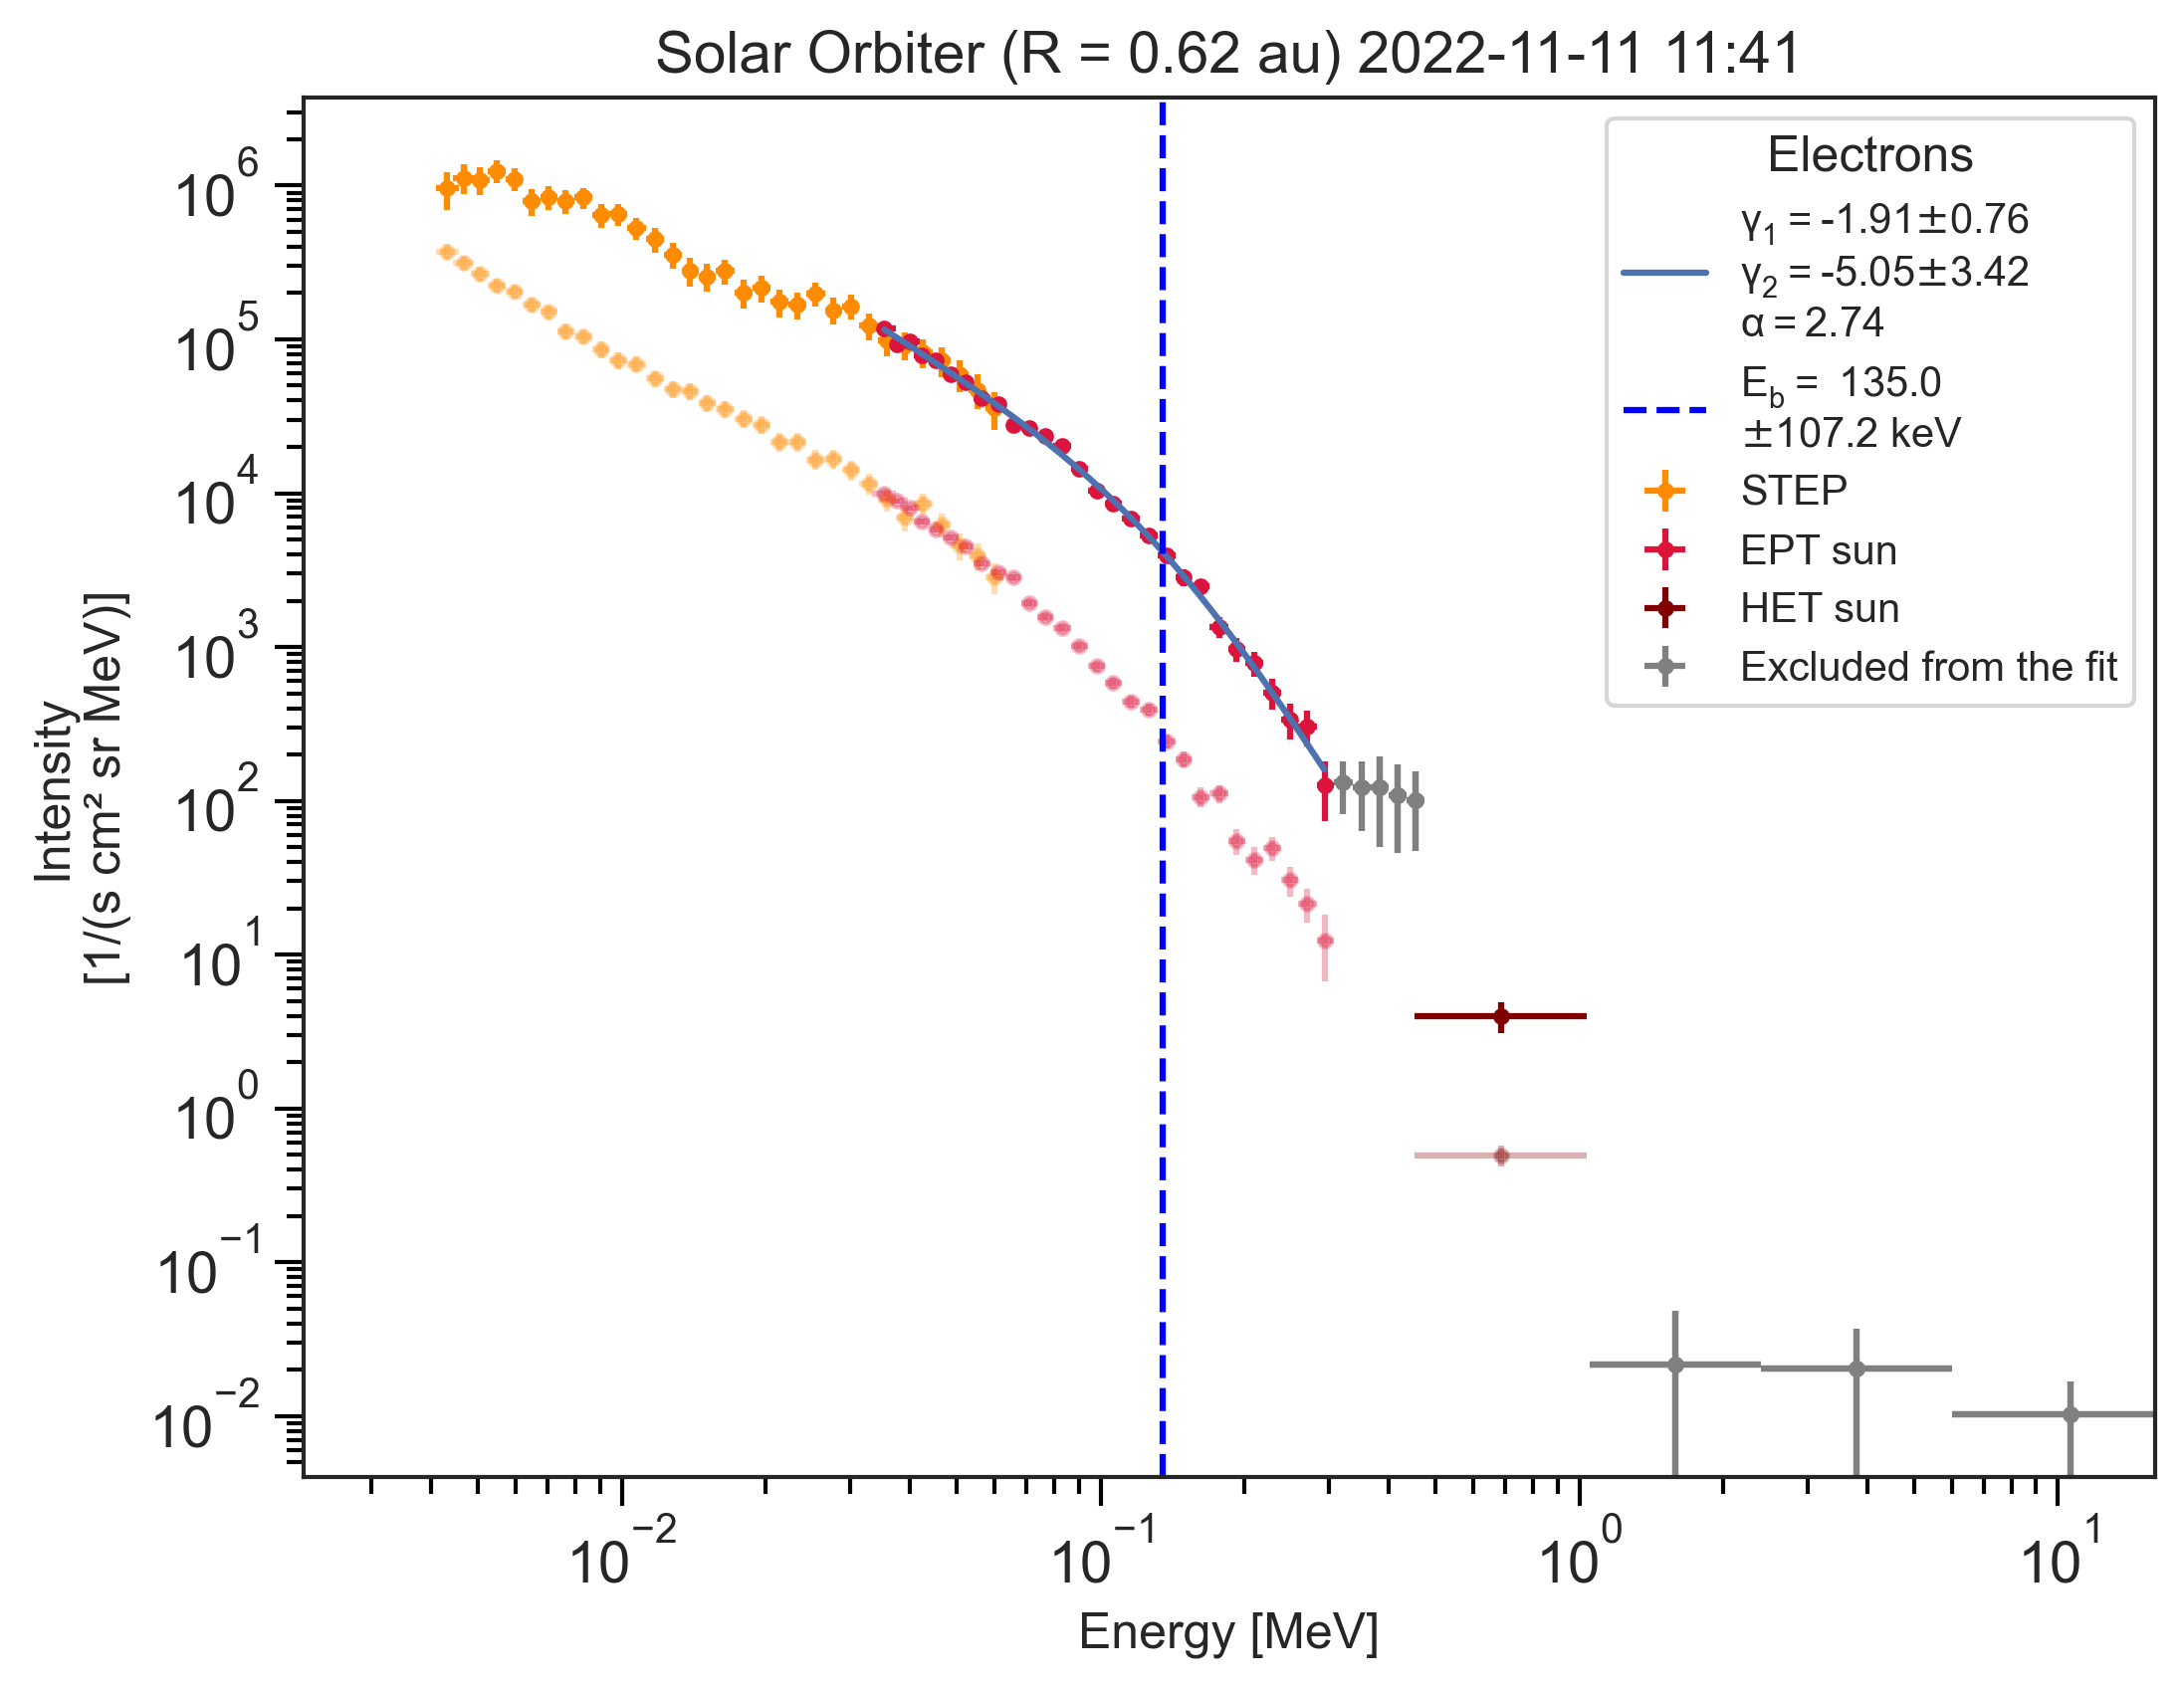

In [35]:
centre_pix = True
if step:
    FIT_DATA(path_to_folder, date, averaging = averaging, fit_type= fit_type, step = step, ept = ept, het = het, 
             direction = direction, which_fit = which_fit, channels_to_exclude = excluded_channels, 
             sigma = sigma, rel_err = rel_err, frac_nan_threshold = frac_nan_threshold, fit_to = fit_to, 
             e_min = e_min, e_max = e_max, g1_guess = g1_guess, g2_guess = g2_guess, g3_guess = g3_guess, 
             c1_guess = c1_guess, alpha_guess = alpha_guess, beta_guess = beta_guess, 
             break_guess_low = break_guess_low, break_guess_high = break_guess_high, cut_guess = cut_guess, 
             exponent_guess = exponent, use_random = use_random, iterations = random_iterations, 
             leave_out_1st_het_chan = leave_out_1st_het_chan, shift_step_data = shift_step_data, 
             auto_shift = auto_shift, shift_factor = shift_factor, save_fig = saving, 
             save_pickle = False, save_fit_variables = saving, save_fitrun = saving, 
             legend_details = detailed_legend, ion_correction = ion_correction, 
             bg_subtraction = bg_subtraction, fit_to_separate_folder = plot_n_data_folders,  
             centre_pix = centre_pix, quality_factor = qf_pix, fsize = f_size, legend_outside = legend_outside, 
             no_legend = no_legend, do_not_plot_bad_channels = do_not_plot_bad_channels, title_of_plot = title,
             make_the_fit = True)


In [36]:
# JUST RUN SO THE DATA FROM THE PREVIOUS CELL GETS SAVED
center_pix = True

pix = ''
if pixels and step:
    pix = '-centre_pix'
        
if save_fit_run_variables_to_separate_folders and step and pixels:
    fit_var_file = date_folder+'-fit-result-variables_'+fit_type+'-'+fit_to+'-'+which_fit+'-l2-'+averaging_str + '_averaging-'+direction+pix+'.csv'
    run_var_file = date_folder+'-all-fit-variables_'+fit_type+'-'+fit_to+'-'+which_fit+'-l2-'+averaging_str + '_averaging-'+direction+pix+'.csv'

    save_fit_and_run_variables_to_separate_folders(path, date_folder, fit_var_file, run_var_file)
    

2026-09-16 17:10:27 - sunpy - INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144)


INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144) [sunpy.coordinates.ephemeris]
1.1208964774777732
SHIFT FACTOR: 1.1208964774777732


/Users/annafed/Desktop/GitHub/SolOEPD-Plot-n-Fit-SEE/my_power_law_fits_odr.py:122: RuntimeWarning: overflow encountered in power
  * ((x**alpha + E_break**alpha)
/Users/annafed/Desktop/GitHub/SolOEPD-Plot-n-Fit-SEE/my_power_law_fits_odr.py:122: RuntimeWarning: invalid value encountered in scalar power
  * ((x**alpha + E_break**alpha)
/Users/annafed/Desktop/GitHub/SolOEPD-Plot-n-Fit-SEE/my_power_law_fits_odr.py:123: RuntimeWarning: overflow encountered in scalar power
  / (0.1**alpha + E_break**alpha)) ** ((gamma2 - gamma1) / alpha))
/Users/annafed/Desktop/GitHub/SolOEPD-Plot-n-Fit-SEE/my_power_law_fits_odr.py:123: RuntimeWarning: invalid value encountered in scalar power
  / (0.1**alpha + E_break**alpha)) ** ((gamma2 - gamma1) / alpha))
/Users/annafed/Desktop/GitHub/SolOEPD-Plot-n-Fit-SEE/my_power_law_fits_odr.py:122: RuntimeWarning: divide by zero encountered in divide
  * ((x**alpha + E_break**alpha)
/Users/annafed/Desktop/GitHub/SolOEPD-Plot-n-Fit-SEE/my_power_law_fits_odr.py:122: R

X limits: (np.float64(0.0021616718065), np.float64(15.934504319999999))
Y limits: (np.float64(0.004001891427210157), np.float64(4071496.9883006513))
X major: 8
X minor: 64
Y major: 13
Y minor: 104
X limits: (np.float64(0.0021616718065), np.float64(15.934504319999999))
Y limits: (np.float64(0.004001891427210157), np.float64(4071496.9883006513))


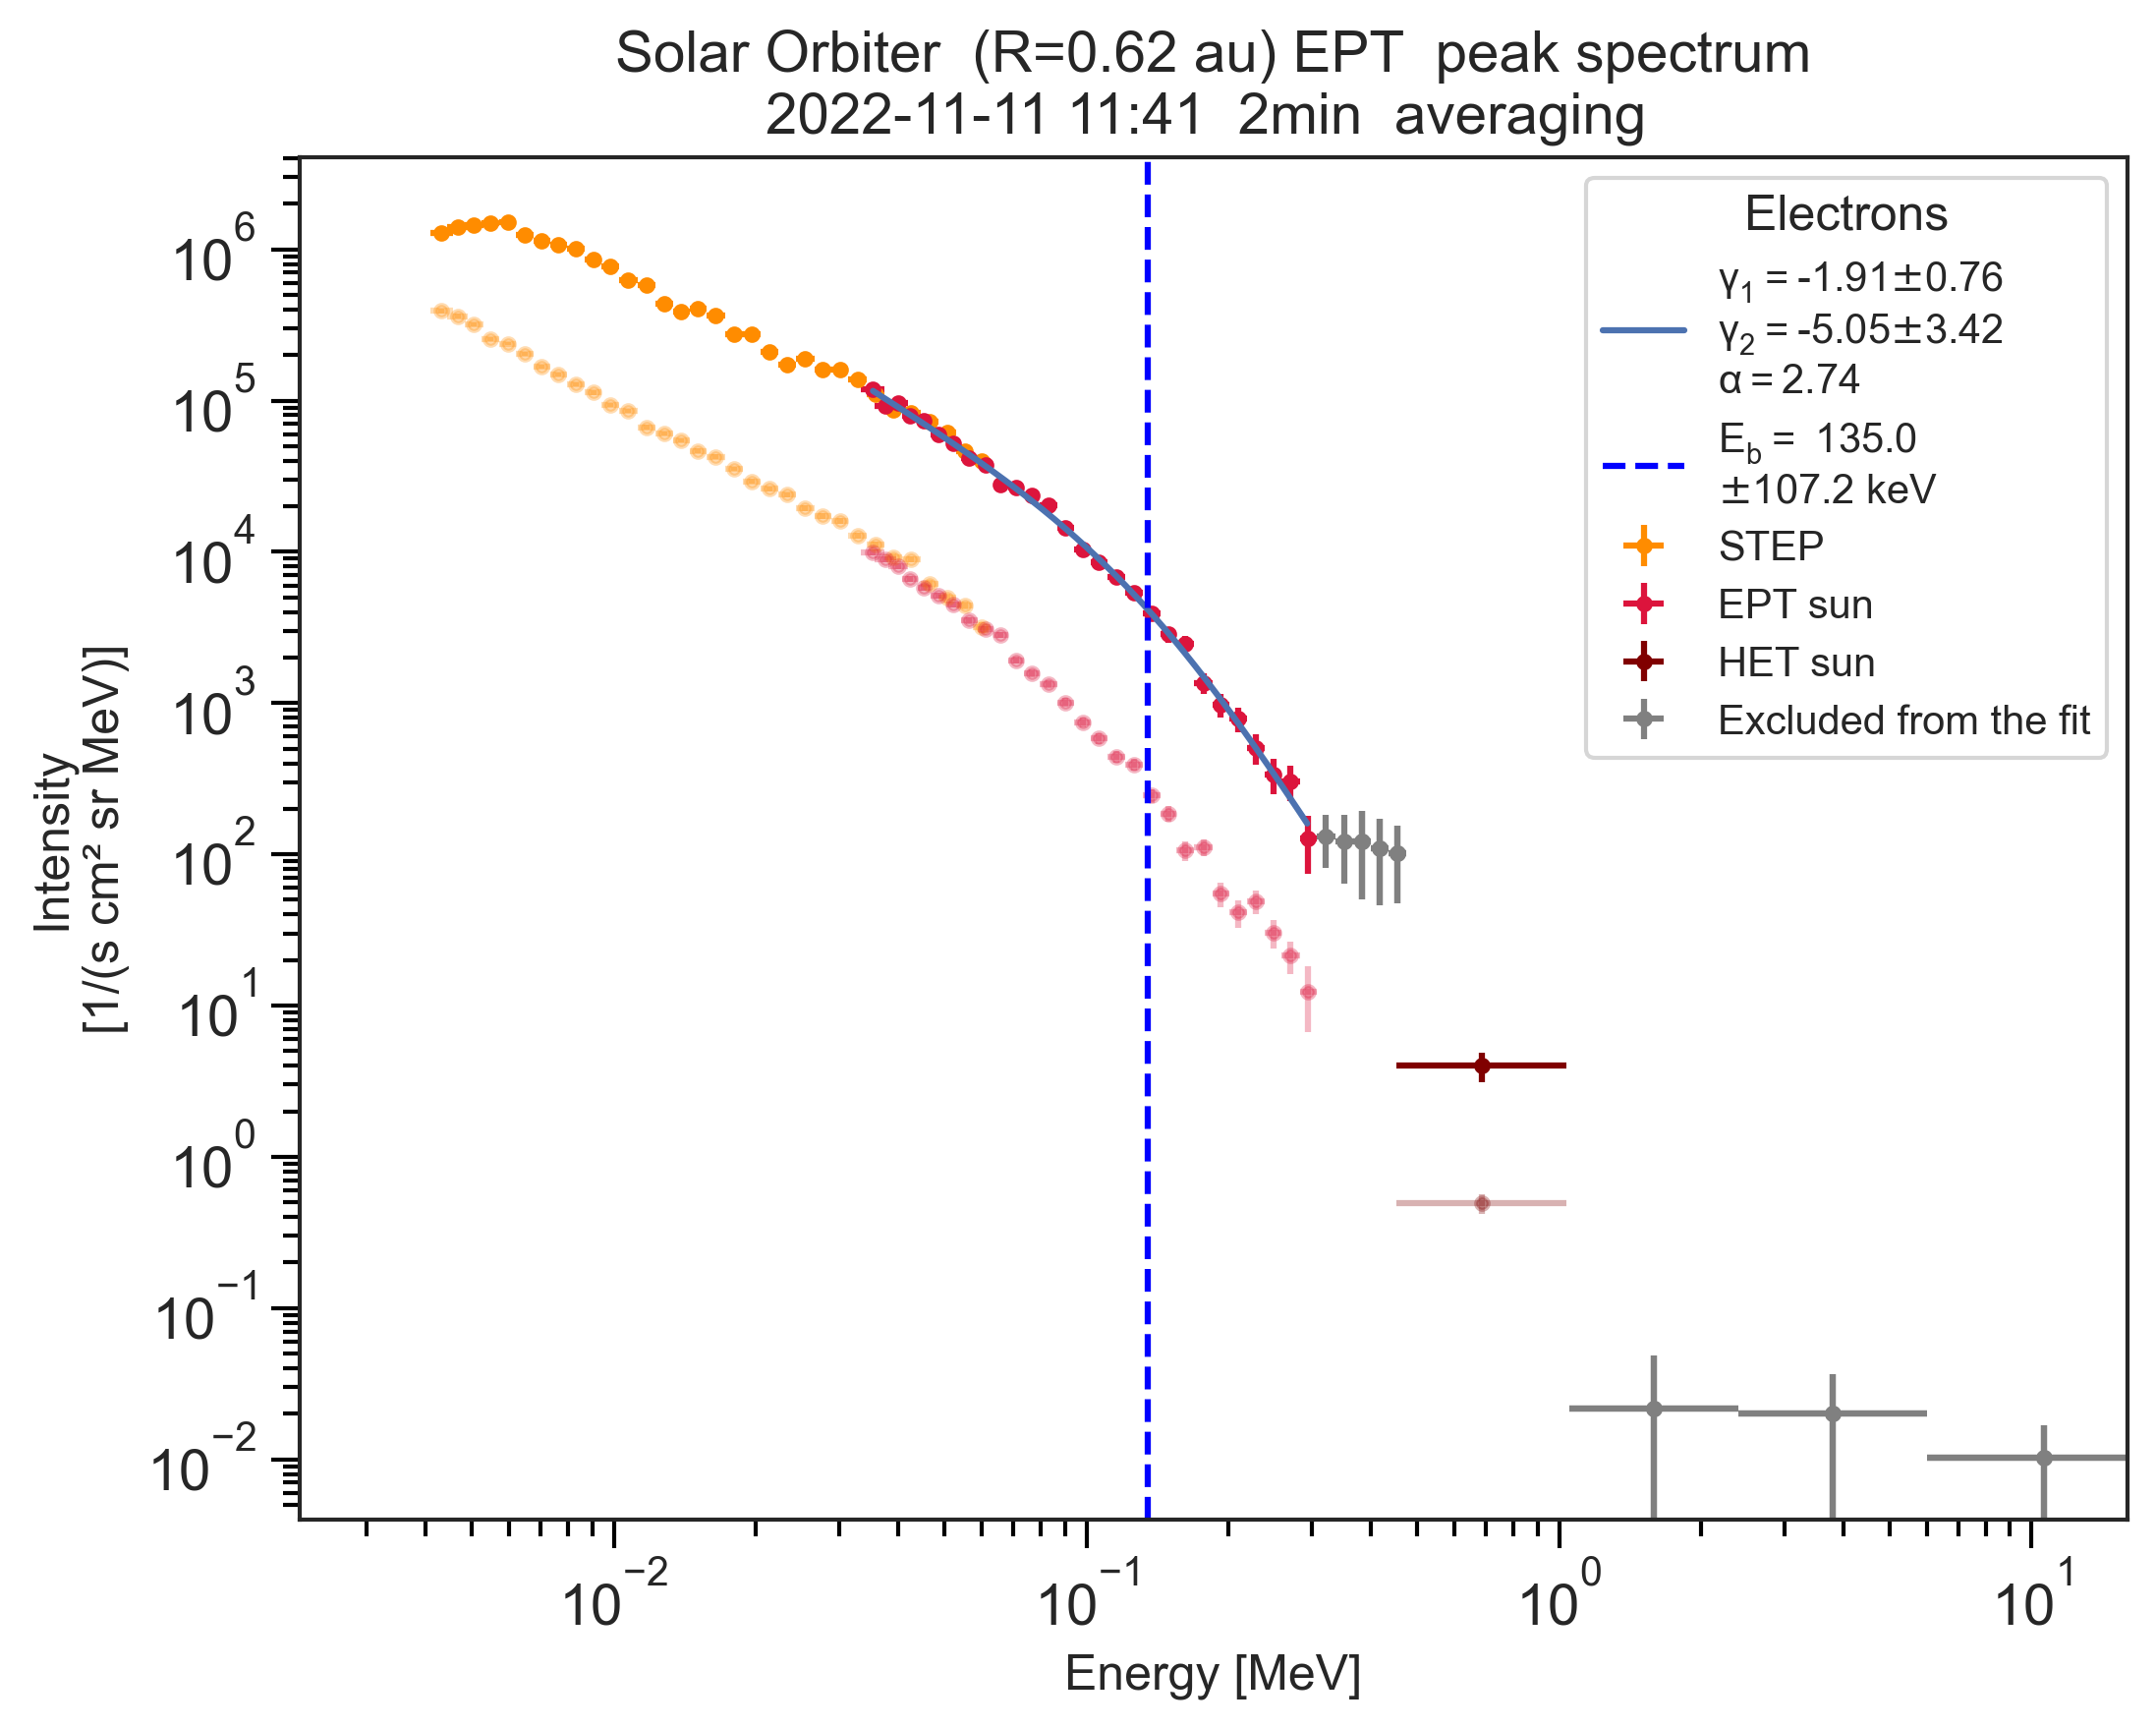

In [37]:
centre_pix = False

FIT_DATA(path_to_folder, date, averaging = averaging, fit_type= fit_type, step = step, ept = ept, het = het, direction = direction,
         which_fit = which_fit, sigma = sigma, rel_err = rel_err, frac_nan_threshold = frac_nan_threshold, fit_to = fit_to, 
         e_min = e_min, e_max = e_max, g1_guess = g1_guess, g2_guess = g2_guess, g3_guess = g3_guess, c1_guess = c1_guess, 
         alpha_guess = alpha_guess, beta_guess = beta_guess, break_guess_low = break_guess_low, break_guess_high = break_guess_high, cut_guess = cut_guess, exponent_guess = exponent,
         use_random = use_random, iterations = random_iterations, leave_out_1st_het_chan = leave_out_1st_het_chan, shift_step_data = shift_step_data, auto_shift = auto_shift,
         shift_factor = shift_factor, save_fig = saving, save_pickle = False, save_fit_variables = saving, save_fitrun = saving, legend_details = detailed_legend, 
         ion_correction = ion_correction, bg_subtraction = bg_subtraction, fit_to_separate_folder = plot_n_data_folders,  centre_pix = centre_pix, quality_factor = qf, fsize = f_size, legend_outside = legend_outside, no_legend = no_legend, do_not_plot_bad_channels = do_not_plot_bad_channels)


In [38]:
# JUST RUN SO THE DATA FROM THE PREVIOUS CELL GETS SAVED
if save_fit_run_variables_to_separate_folders:
    fit_var_file = (date_folder + '-fit-result-variables_' +
        fit_type + '-' + fit_to + '-' + which_fit +
        '-l2-' + averaging_str + '_averaging-' + direction + '.csv')

    run_var_file = (date_folder + '-all-fit-variables_' +
        fit_type + '-' + fit_to + '-' + which_fit +
        '-l2-' + averaging_str + '_averaging-' + direction + '.csv')

    save_fit_and_run_variables_to_separate_folders(path, date_folder, fit_var_file, run_var_file)

2026-09-16 17:10:29 - sunpy - INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144)


INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144) [sunpy.coordinates.ephemeris]
1.2705168327862233
SHIFT FACTOR: 1.2705168327862233
X limits: (np.float64(0.0021616718065), np.float64(15.934504319999999))
Y limits: (np.float64(0.004017790084689617), np.float64(3746220.7220880957))
X major: 8
X minor: 64
Y major: 13
Y minor: 104
X limits: (np.float64(0.0021616718065), np.float64(15.934504319999999))
Y limits: (np.float64(0.004017790084689617), np.float64(3746220.7220880957))


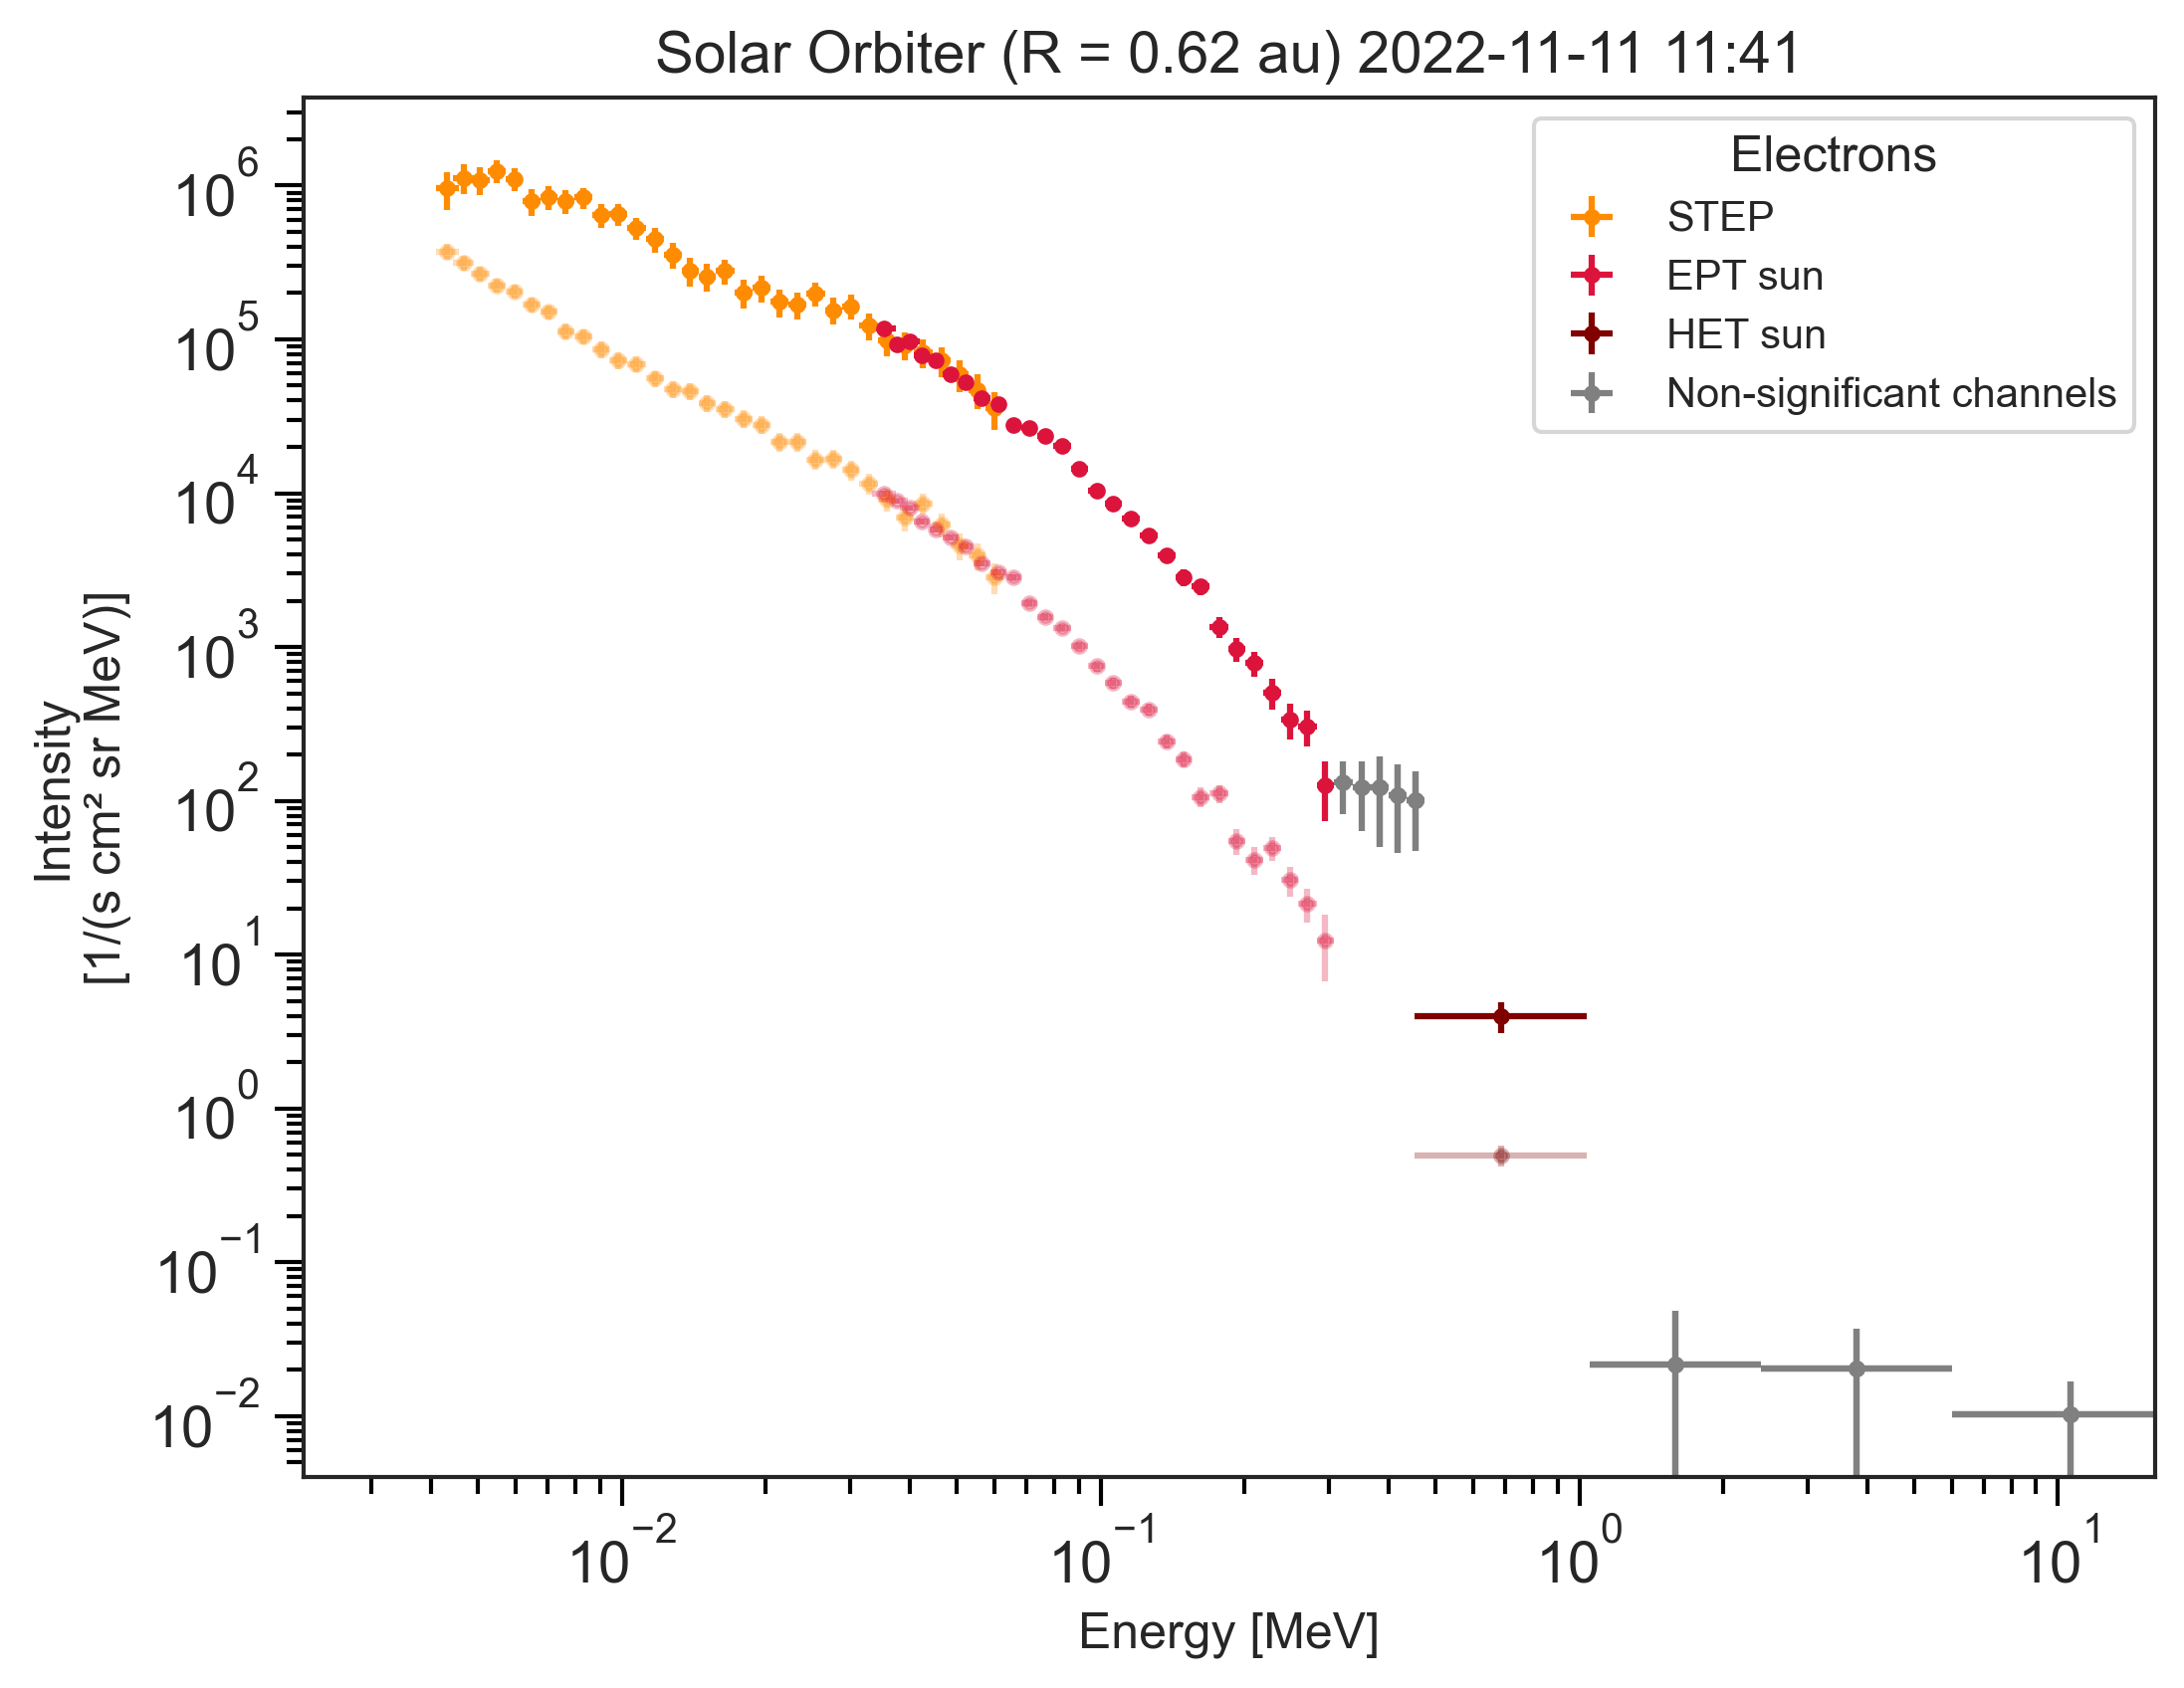

In [39]:
# NO FIT JUST PLOT 
# JUST RUN
centre_pix = True
if step:
    FIT_DATA(path_to_folder, date, averaging = averaging, fit_type= fit_type, step = step, ept = ept, het = het, 
             direction = direction, which_fit = which_fit, channels_to_exclude = excluded_channels, 
             sigma = sigma, rel_err = rel_err, frac_nan_threshold = frac_nan_threshold, fit_to = fit_to, 
             e_min = e_min, e_max = e_max, g1_guess = g1_guess, g2_guess = g2_guess, g3_guess = g3_guess, 
             c1_guess = c1_guess, alpha_guess = alpha_guess, beta_guess = beta_guess, 
             break_guess_low = break_guess_low, break_guess_high = break_guess_high, cut_guess = cut_guess, 
             exponent_guess = exponent, use_random = use_random, iterations = random_iterations, 
             leave_out_1st_het_chan = leave_out_1st_het_chan, shift_step_data = shift_step_data, 
             auto_shift = auto_shift, shift_factor = shift_factor, save_fig = saving, 
             save_pickle = False, save_fit_variables = saving, save_fitrun = saving, 
             legend_details = detailed_legend, ion_correction = ion_correction, 
             bg_subtraction = bg_subtraction, fit_to_separate_folder = plot_n_data_folders,  
             centre_pix = centre_pix, quality_factor = qf_pix, fsize = f_size, legend_outside = legend_outside, 
             no_legend = no_legend, do_not_plot_bad_channels = do_not_plot_bad_channels, title_of_plot = title,
             make_the_fit = False)


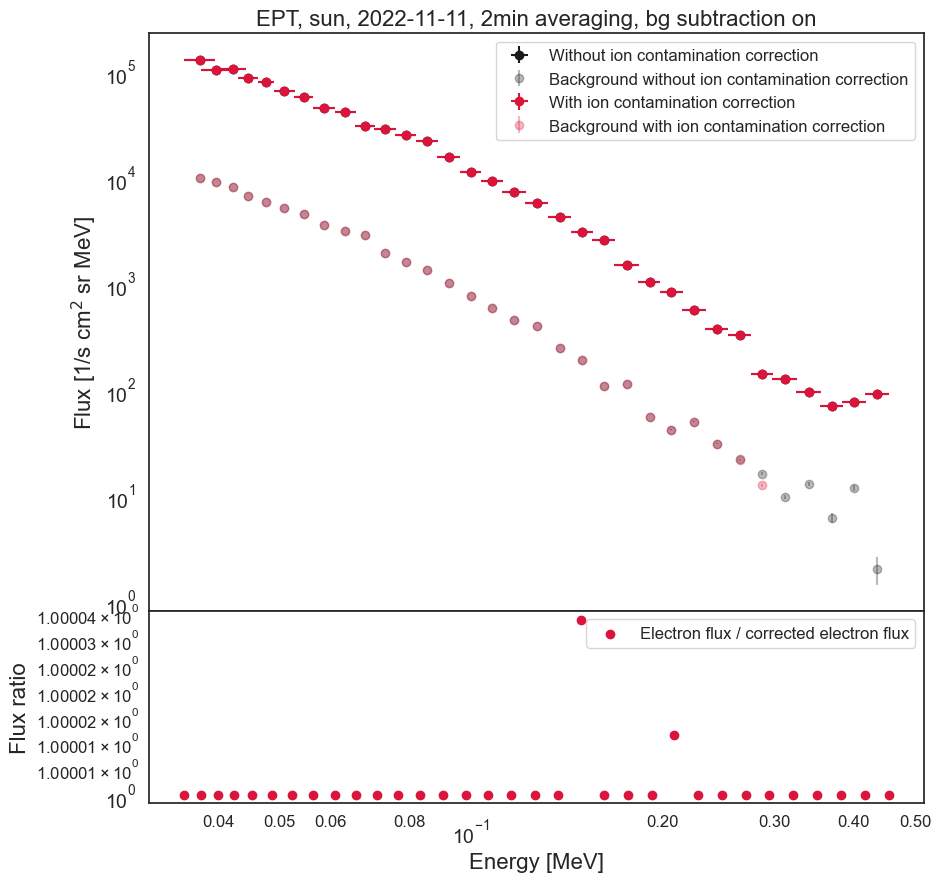

In [40]:
import matplotlib.ticker as ticker

if bg_subtraction == True:
    bg_subt = 'on'
else:
    bg_subt = 'off'

data_ept_no_ion_corr = extract_particle_data(df_electrons_ept, energies_ept, plot_start, plot_end, t_inj, bgstart = bg_start, 
                                     bgend = bg_end, bg_distance_from_window = bg_distance_from_window, bg_period = bg_period, 
                                     travel_distance = travel_distance, travel_distance_second_slope=travel_distance_second_slope, 
                                     fixed_window=fixed_window, instrument = 'ept', data_type = 'l2', averaging=averaging, masking=True, 
                                     ion_conta_corr=False, df_protons = df_protons_ept, species = species)

write_to_csv(data_ept_no_ion_corr, date = date_string, path=path_to_folder, direction = direction, species = species)


file_path = path + date.strftime('%Y-%m-%d-%H%M') +'/'
os.getcwd()
os.chdir(file_path)
data_no_ion_corr = 'electron_data-'+ date.strftime('%Y-%m-%d') + '-EPT-' + direction + '-L2-' + averaging + '_averaging.csv'
data_ion_corr = 'electron_data-'+ date.strftime('%Y-%m-%d') + '-EPT-' + direction + '-L2-' + averaging+ '_averaging-ion_corr.csv'
df1 = pd.read_csv(data_no_ion_corr, sep=';')  
df2 = pd.read_csv(data_ion_corr, sep=';')

y1 = df1.Flux_peak
y2 = df2.Flux_peak
x = df1.Primary_energy
ratio = y1 / y2

fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1,1/3])

def color_plot(direction):
    color_dict = {'sun': 'crimson', 'asun': 'orange', 'north': 'darkslateblue', 'south': 'c'}
    color = color_dict.get(direction.lower(), '')
    ax1 = fig.add_subplot(gs[0])
    ax1.errorbar(df1.Primary_energy, df1.Flux_peak, df1.Energy_error_low, df1.Energy_error_high, color='k', fmt='o', label='Without ion contamination correction') 
    ax1.errorbar(df1.Primary_energy, df1.Background_flux, df1.rel_backsub_peak_err, color='k', fmt='o', alpha = 0.3, label='Background without ion contamination correction')
    ax1.errorbar(df2.Primary_energy, df2.Flux_peak, df2.Energy_error_low, df2.Energy_error_high, color=color, fmt='o', label='With ion contamination correction') 
    ax1.errorbar(df2.Primary_energy, df2.Background_flux, df2.rel_backsub_peak_err, color=color, fmt='o', alpha = 0.3, label = 'Background with ion contamination correction')

    ax1.set_title('EPT, ' + direction + ', ' + date.strftime('%Y-%m-%d') + ', ' + str(averaging) + ' averaging, bg subtraction ' + bg_subt, fontsize = 16)
    ax1.set_ylabel(r'Flux [1/s cm$^{2}$ sr MeV]', fontsize = 16)
    ax1.tick_params(axis='y', which='major', labelsize=14)
    ax1.legend(loc=0, fontsize = 12)
    ax1.set_yscale('log')
    ax1.set_xscale('log')

    ax2 = fig.add_subplot(gs[1])
    ax2.scatter(x, ratio, color=color, label='Electron flux / corrected electron flux')

    ax2.set_xlabel('Energy [MeV]', fontsize=16)
    ax2.set_ylabel('Flux ratio', fontsize=16)
    ax2.set_yscale('log')
    ax2.set_xscale('log')
    ax2.legend(loc=0, fontsize=12)

    ax2.tick_params(axis='x', which='minor', labelsize=12)
    ax2.tick_params(axis='x', which='major', labelsize=14)
    ax2.tick_params(axis='y', which='major', labelsize=14)
    ax2.tick_params(axis='y', which='minor', labelsize=12)
    ax2.xaxis.set_minor_formatter(FormatStrFormatter("%.2f"))

    minor_positions = [0.03, 0.04, 0.05, 0.06, 0.08, 0.20, 0.30, 0.40, 0.50]
    minor_locator = ticker.FixedLocator(minor_positions)
    ax2.xaxis.set_minor_locator(minor_locator)

color_plot(direction)

plt.subplots_adjust(hspace=0)
plt.savefig(path +date_folder+ '/plots/EPT_ion_corr_spectra_comparison-'+direction+'-'+averaging+'.png', dpi=300, bbox_inches='tight')
#folder = 
#name = 'Ion_contamination_EPT_' + direction + '_' + date.strftime('%Y-%m-%d') + '_' + str(averaging) + '_averaging.jpg'
#plt.savefig(os.path.join(folder, name), bbox_inches="tight")  

In [41]:
date

datetime.datetime(2022, 11, 11, 11, 41)